# DeepSeek and Shortest Path in a Weighted Graph

# 1. Introduction

__What exactly is DeepSeek?__

From https://www.straitstimes.com/business/companies-markets/what-is-chinas-deepseek-and-why-is-it-freaking-out-the-ai-world:

"DeepSeek was founded in 2023 by Mr Liang Wenfeng, the chief of AI-driven quant hedge fund High-Flyer. The company develops AI models that are open source, meaning the developer community at large can inspect and improve the software. Its mobile app surged to the top of iPhone download charts in the US after its release in early January. 

The app distinguishes itself from other chatbots like OpenAI’s ChatGPT by articulating its reasoning before delivering a response to a prompt.

The company claims its new AI model, R1, offers performance on a par with OpenAI’s latest and has granted licence for individuals interested in developing chatbots using the technology to build on it."

__Vibe Coding__

I was curious about "vibe coding" with DeepSeek. 

Vibe coding is a new concept in the world of software development.
From https://www.geeksforgeeks.org/what-is-vibe-coding/:

"Vibe Coding is a new concept in the world of software development and coding education, and it has quickly gained attention for its unique approach. Vibe coding focuses on making the coding experience more interactive, creative, and enjoyable, shifting away from the more traditional, rigid structures often associated with learning programming. This process is all about creating a more engaging and emotional connection between the coder and the code, making it more of an art form than just a technical task."

"The process of Vibe Coding is iterative and interactive, involving several steps:

1. Description: Users provide a natural language prompt, such as "Create a simple web page that displays the current weather for a city the user enters."
2. Generation: An AI model, tuned for coding, generates the code based on the description. Tools like Cursor Composer with Sonnet or Replit Agent are commonly used.
3. Testing and Refinement: The user tests the generated code, provides feedback, and asks the AI to make adjustments, often without going into the code’s syntax.
4. Iteration: This cycle continues until the software meets the desired functionality."

So I downloaded the DeepSeek mobile app and asked 2 questions related to quantum computing and graphs:

1. __Please write a novel qiskit code to find the shortest path between 2 vertices in a weighted graph and let that code be 0.18.1 qiskit compatible.__
2. __Please write 0.18.1 qiskit compatible code for the same problem, but based on a Grover's search algorithm.__

The code produced by DeepSeek for the first question was an approach that incorporated the high-level idea of parametrized quantum walks and adaptive tuning. The core idea is to use tunable parameters theta for mixing, and gamma for phase feedback. Essentially, fixed Grover iterations are replaced with adaptive steps.

The code produced by DeepSeek for the second question was pretty much a standard implementation of Grover's search algorithm based on an Oracle and an iterative application of the Oracle and diffusion operator, no surprises here.

For a small 4-nodes weighted sample graph, both codes generated the correct smallest path between specified nodes.

For a 10-node weighted graph, some incorrect smallest paths for both codes prompted some code tweaks and updates to resolve these issues.
However, for the same 10-nodes weighted graphs, there were some start and end node pairs for which both updated codes could
not generate the correct smallest path, so further investigation is needed into these issues.

This notebook documents my experience.

# 2. Key Inovations of novel DeepSeek code for the first question:

1. __Prameterized Quantum Walk__: the core idea of using tunable parameters
   theta for mixing, gamma for phase feedback.
   Fixed Grover iterations are replaced with adaptive steps.
2. __Hybrid Node Encoding__:qubit used to represent nodes (1 qubit = 1 node), maintaining compatibility
   with small graphs
3. __Weight Integration__: edge weights are incorporated classically during path validation.

- Weights are only used classically for scoring.
- Simplified Phase Feedback uses basic Rz gates for phase adjustments instead of QFT-based estimation due to circuit depth constraints.
- COBYLA optimizer handles  most "adaptation", reducing the quantum feedback role
- No Continuous-Time Walk: discrete steps are implemented with Ry/Rz gates rather than true continuous-time evolution.
- With respect to resource scaling, lacks logarithmic qubit scaling for weights (uses classical post-processing instead).

In summary, the approach incorporates the high-level idea of parametrized quantum walks and adaptive tuning.

In [2]:
import qiskit
print(qiskit.version.get_version_info())

C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\equivalence.py:18: DeprecationWarning: The retworkx package is deprecated and has been renamed to rustworkx. Rustworkx is a drop-in replacement and can be used by replacing `import retworkx` with import `rustworkx`. 
  import retworkx as rx
C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\version.py:20: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


0.18.1


In [2]:
from qiskit import Aer, QuantumCircuit, execute
from qiskit.circuit import Parameter
from qiskit.aqua.components.optimizers import COBYLA
from qiskit.aqua import QuantumInstance
import networkx as nx
import numpy as np
from math import pi
import matplotlib.pyplot as plt

class QuantumShortestPathSolver:
    def __init__(self, graph, start, end):
        self.graph = graph
        self.start = start
        self.end = end
        self.num_nodes = len(graph.nodes())
        self.node_map = {node: idx for idx, node in enumerate(graph.nodes())}
        self.reverse_map = {idx: node for node, idx in self.node_map.items()}
        
        # Parameters
        self.theta = Parameter('θ')
        self.gamma = Parameter('γ')
        
        # Create circuit
        self.circuit = QuantumCircuit(self.num_nodes, self.num_nodes)
        self.build_circuit()
    
    def initialize_state(self):
        """Initialize quantum state with start node"""
        start_idx = self.node_map[self.start]
        self.circuit.x(start_idx)
        self.circuit.h(range(self.num_nodes))
    
    def quantum_walk_step(self):
        """Implement a quantum walk step with parameters"""
        # Mixing operator
        for i in range(self.num_nodes):
            self.circuit.ry(self.theta, i)
        
        # Mark end node
        end_idx = self.node_map[self.end]
        self.circuit.z(end_idx)
    
    def apply_phase_feedback(self):
        """Apply parameterized phase feedback"""
        for i in range(self.num_nodes):
            self.circuit.rz(self.gamma, i)
    
    def build_circuit(self, iterations=2):
        """Build the complete quantum circuit"""
        self.initialize_state()
        for _ in range(iterations):
            self.quantum_walk_step()
            self.apply_phase_feedback()
        self.circuit.measure(range(self.num_nodes), range(self.num_nodes))
    
    def is_valid_path(self, path):
        """Check if path is valid"""
        if not path or path[0] != self.start or path[-1] != self.end:
            return False
        for i in range(len(path)-1):
            if not self.graph.has_edge(path[i], path[i+1]):
                return False
        return True
    
    def calculate_path_length(self, path):
        """Calculate path length"""
        return sum(self.graph[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

class ParameterTuner:
    def __init__(self, solver, shots=512):
        self.solver = solver
        self.shots = shots
        self.backend = Aer.get_backend('qasm_simulator')
        self.quantum_instance = QuantumInstance(self.backend, shots=shots)
        
    def objective_function(self, params):
        """Objective function for optimization"""
        # Convert parameters to dictionary for binding
        param_dict = {self.solver.theta: params[0], 
                     self.solver.gamma: params[1]}
        
        try:
            # Bind parameters
            bound_circuit = self.solver.circuit.bind_parameters(param_dict)
            
            # Execute
            job = execute(bound_circuit, self.backend, shots=self.shots)
            result = job.result()
            counts = result.get_counts()
            
            # Calculate score based on valid paths
            score = 0
            for bitstring, count in counts.items():
                path = [self.solver.reverse_map[i] for i, bit in enumerate(reversed(bitstring)) if bit == '1']
                if self.solver.is_valid_path(path):
                    length = self.solver.calculate_path_length(path)
                    score += (count/self.shots) * (1/length)
            
            return -score  # Return negative for minimization
        
        except Exception as e:
            print(f"Error during execution: {e}")
            return float('inf')  # Return worst possible score

    def tune_parameters(self, initial_params=None, maxiter=80):#maxiter=20
        """Parameter tuning using Qiskit 0.18.1 COBYLA"""
        if initial_params is None:
            initial_params = [pi/4, pi/8]  # Default initial values
        
        # Create optimizer
        optimizer = COBYLA(maxiter=maxiter, tol=0.01)
        
        # Optimization
        ret = optimizer.optimize(num_vars=2, 
                               objective_function=self.objective_function,
                               initial_point=initial_params)
        
        optimal_params = ret[0]
        optimal_value = ret[1]
        
        print(f"Optimization results:")
        print(f"Best θ: {optimal_params[0]:.4f}")
        print(f"Best γ: {optimal_params[1]:.4f}")
        print(f"Best score: {-optimal_value:.4f}")
        
        return optimal_params[0], optimal_params[1]

def run_example(G,start,end):
    # Initialize solver
    solver = QuantumShortestPathSolver(G, start, end)
    
    # Run parameter tuning
    print("Starting parameter tuning...")
    tuner = ParameterTuner(solver, shots=2048) #shots=512
    best_theta, best_gamma = tuner.tune_parameters(maxiter=60) #maxiter=15
    
    # Solve with tuned parameters
    print("\nRunning with tuned parameters...")
    param_dict = {solver.theta: best_theta, solver.gamma: best_gamma}
    bound_circuit = solver.circuit.bind_parameters(param_dict)
    result = execute(bound_circuit, Aer.get_backend('qasm_simulator'), shots=1024).result()
    counts = result.get_counts()
    
    # Process results
    solutions = []
    for bitstring, count in counts.items():
        path = [solver.reverse_map[i] for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        if solver.is_valid_path(path):
            length = solver.calculate_path_length(path)
            solutions.append((path, length, count))
    
    # Sort by length then by count
    solutions.sort(key=lambda x: (x[1], -x[2]))
    
    # Display results
    if solutions:
        print("\nTop solutions:")
        for i, (path, length, count) in enumerate(solutions[:3], 1):
            print(f"{i}. Path: {path}, Length: {length}, Count: {count}")
    else:
        print("No valid paths found.")
        
    # Draw circuit
    print("\nFinal circuit:")
    bound_circuit.draw(output='mpl', fold=100)
    plt.show()

C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\__init__.py:86: DeprecationWarning: The package qiskit.aqua is deprecated. It was moved/refactored to qiskit-terra For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('aqua', 'qiskit-terra')


- correct smallest path returned for below example graph

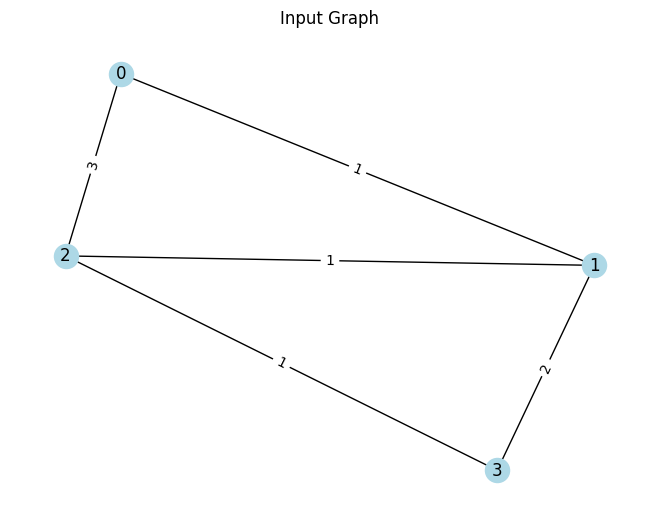

Starting parameter tuning...


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\quantum_instance.py:135: DeprecationWarning: The class qiskit.aqua.QuantumInstance is deprecated. It was moved/refactored to qiskit.utils.QuantumInstance (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_class('aqua.QuantumInstance',
C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\components\optimizers\optimizer.py:49: DeprecationWarning: The package qiskit.aqua.components.optimizers is deprecated. It was moved/refactored to qiskit.algorithms.optimizers (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('aqua.components.optimizers',


Optimization results:
Best θ: 1.6158
Best γ: 0.4916
Best score: 0.0598

Running with tuned parameters...

Top solutions:
1. Path: [0, 1, 3], Length: 3, Count: 67
2. Path: [0, 1, 2, 3], Length: 3, Count: 63
3. Path: [0, 2, 3], Length: 4, Count: 72

Final circuit:


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\tools\pi_check.py:49: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  if not hasattr(inpt._symbol_expr, "expr_free_symbols"):


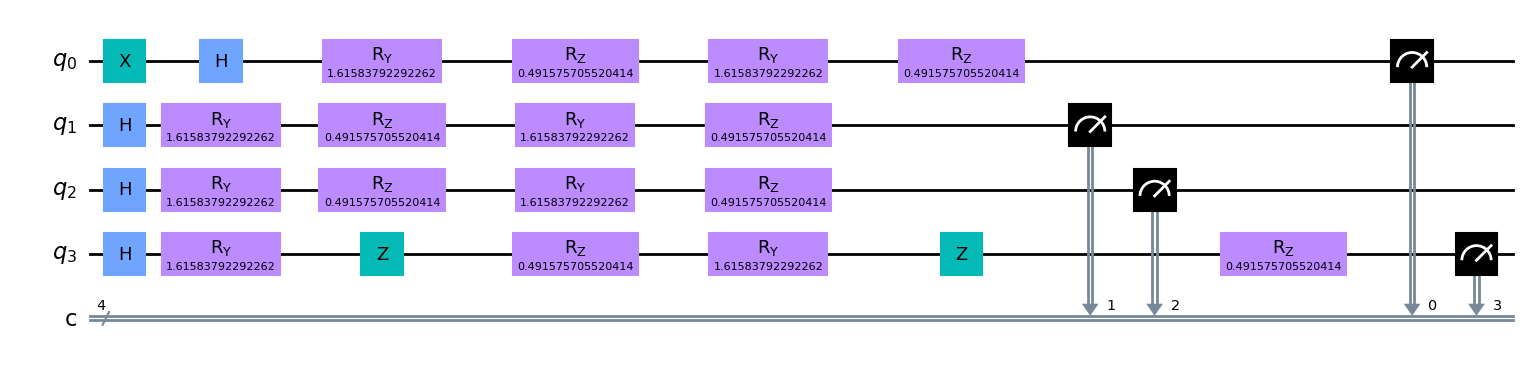

In [4]:
# Run the example
# Create a simple graph
G = nx.Graph()
G.add_weighted_edges_from([(0,1,1), (0,2,3), (1,2,1), (1,3,2), (2,3,1)])

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Input Graph")
plt.show()

run_example(G, 0, 3)

- correct smallest path returned for below 10 nodes weighted graph

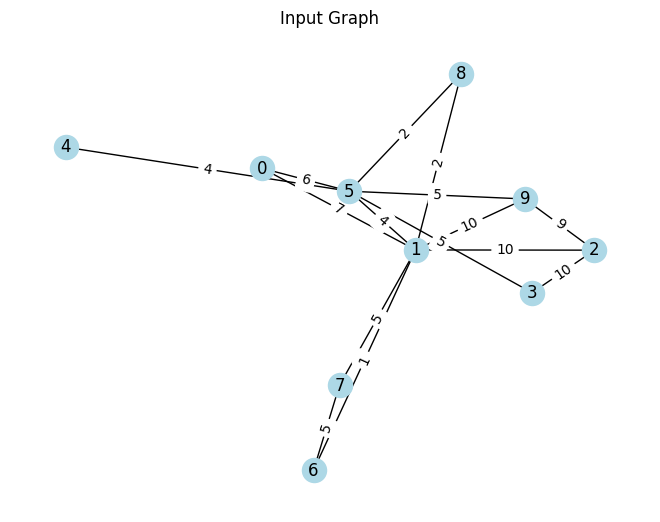

Starting parameter tuning...
Optimization results:
Best θ: 2.6711
Best γ: 0.5277
Best score: 0.0017

Running with tuned parameters...

Top solutions:
1. Path: [0, 1, 7], Length: 12, Count: 19
2. Path: [0, 1, 6, 7], Length: 13, Count: 4

Final circuit:


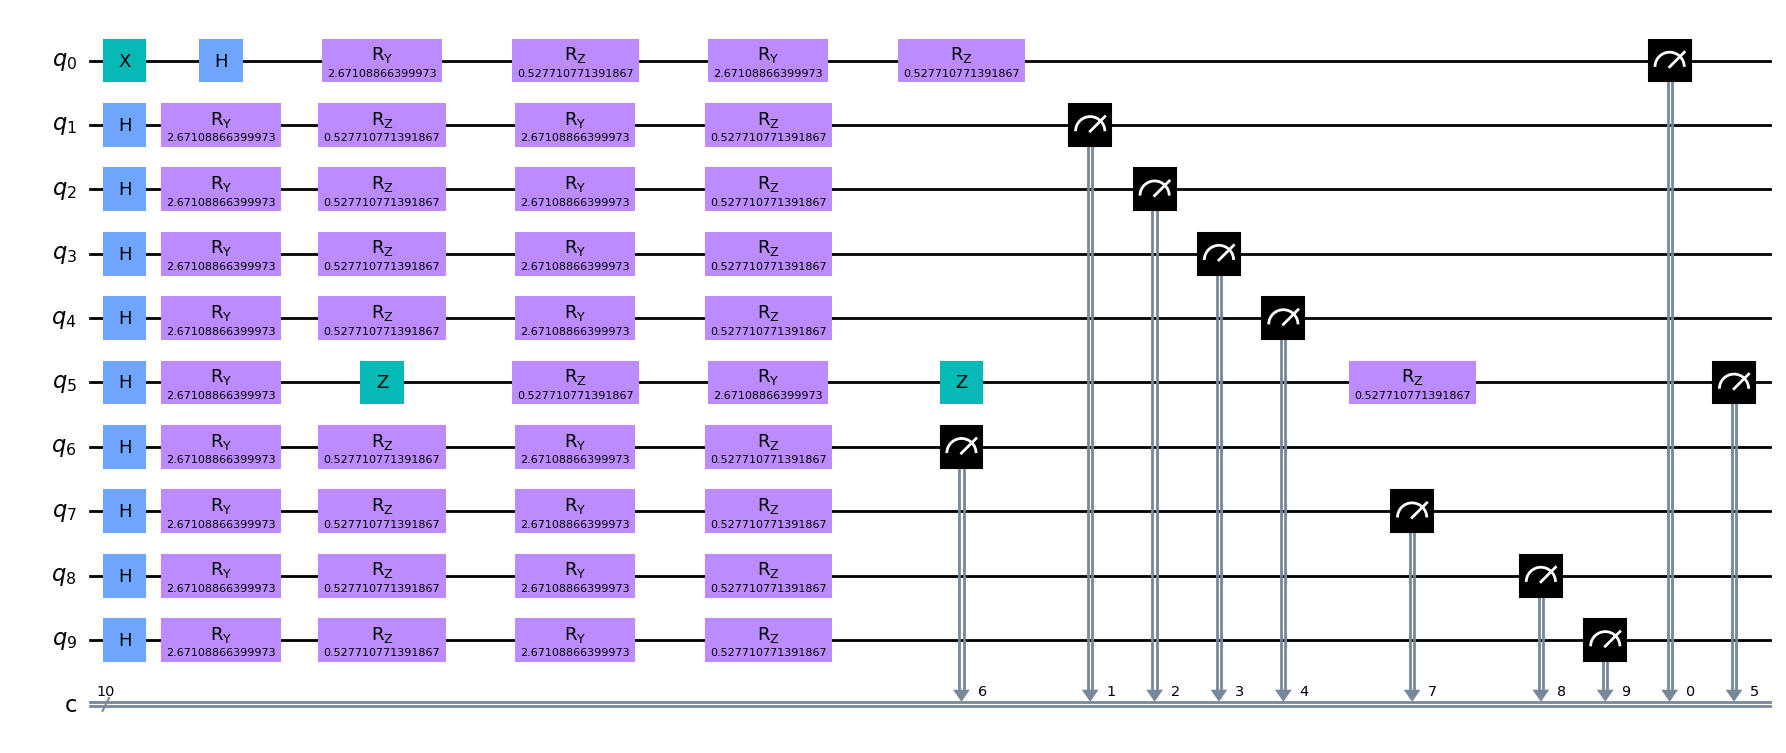

In [5]:
# Define the list of weighted edges (nodes are provided as integers)
weighted_edges = [
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
]

G = nx.Graph()
G.add_weighted_edges_from(weighted_edges)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Input Graph")
plt.show()

run_example(G, 0, 7)

- classical solution confirms the path correctnes

In [3]:
import heapq

def dijkstra(graph, start, end):
    # Priority queue to store (cost, node)
    queue = [(0, start)]
    # Dictionary to store the shortest path to each node
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    # Dictionary to store the path
    previous_nodes = {node: None for node in graph}

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        # If we reached the end node, reconstruct the path
        if current_node == end:
            path = []
            while previous_nodes[current_node] is not None:
                path.insert(0, current_node)
                current_node = previous_nodes[current_node]
            path.insert(0, start)
            return path, distances[end]

        # If a shorter path to current_node has been found, skip processing
        if current_distance > distances[current_node]:
            continue

        # Explore neighbors
        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return None, float('inf')

In [7]:
# Initialize an empty dictionary to store the graph with nodes as strings
graph_dict = {}

# Process each edge to populate the dictionary
for u, v, weight in weighted_edges:
    # Convert nodes to string:
    u_str = str(u)
    v_str = str(v)
    
    # Ensure each node is present in the dictionary
    if u_str not in graph_dict:
        graph_dict[u_str] = {}
    if v_str not in graph_dict:
        graph_dict[v_str] = {}
    
    # Since the graph is undirected, add the edge in both directions
    graph_dict[u_str][v_str] = weight
    graph_dict[v_str][u_str] = weight

# Display the resulting dictionary with string nodes
print("Graph stored as a dictionary with nodes as strings:")
for node, neighbors in graph_dict.items():
    print(f"{node}: {neighbors}")

Graph stored as a dictionary with nodes as strings:
0: {'1': 7, '5': 6}
1: {'0': 7, '2': 10, '5': 4, '6': 1, '7': 5, '8': 2, '9': 10}
5: {'0': 6, '1': 4, '3': 5, '4': 4, '8': 2, '9': 5}
2: {'1': 10, '3': 10, '9': 9}
6: {'1': 1, '7': 5}
7: {'1': 5, '6': 5}
8: {'1': 2, '5': 2}
9: {'1': 10, '2': 9, '5': 5}
3: {'2': 10, '5': 5}
4: {'5': 4}


In [8]:
start_node = '0'
end_node = '7'
path, cost = dijkstra(graph_dict, start_node, end_node)

if path:
    print(f"The shortest path from {start_node} to {end_node} is: {' -> '.join(path)} with a cost of {cost}")
else:
    print(f"No path found from {start_node} to {end_node}")

The shortest path from 0 to 7 is: 0 -> 1 -> 7 with a cost of 12


# 3. Grover approach (the second question)

1. __Oracle Construction__:
   - The oracle identifies all valid paths between the start and end nodes.
   - marks paths with the minimal total weight (shortest paths)
   - Uses multi-controlled X gates to flip the phase of solution states
2. __Grover's algorithm__:
   - creates uniform superposition of all possible paths
   - applies the oracle and diffusion operator iteratively
   - the number of iterations is calculated based on the estimated number of solutions
3. __Result Interpretation__:
   - converts measureent results back to path representations
   - filters valid paths and removes duplicates
   - returns the shortest paths found

__Limitations and Considerations__:
1. __Graphs Size__: works best for small graphs (3-5) nodes due to exponential growth of quantum resources needed
2. __Path Encoding__: uses one qubit per node, which may not be the most efficient for all graphs
3. __Classical Preprocessing__: the oracle creation uses classical computation to find all paths, which
   limits the quantum advantage
4. __Optimal Iterations__: the calculation of optimal Grover iterations assumes knowledge of the number of solutions.

- above 10 nodes weighted graph (Grover's approach did not find the correct path)

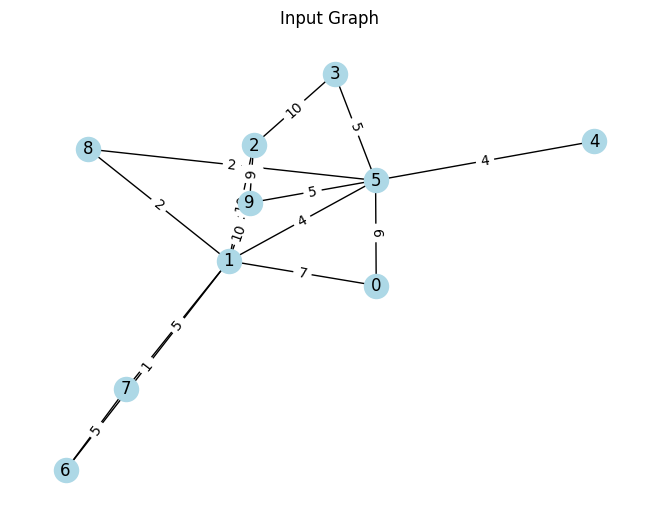

iterations: 26
Measurement results:
{'1000000101': 1, '1100000100': 1018, '0100000101': 1, '1100100001': 1, '0010011110': 1, '1010101010': 1, '1000011101': 1}


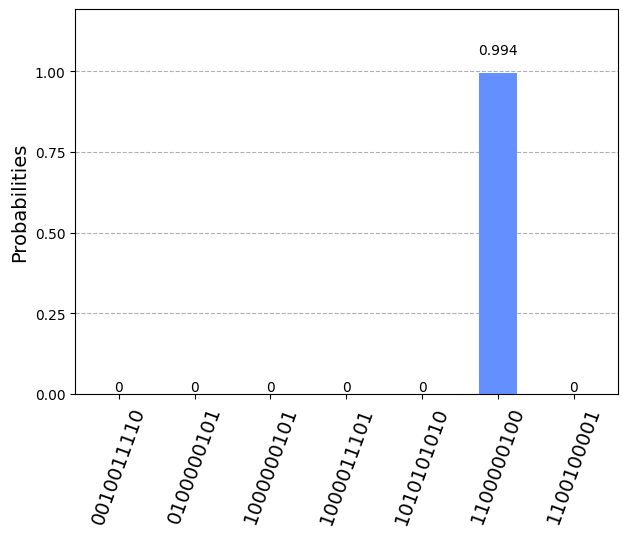

No valid path found.


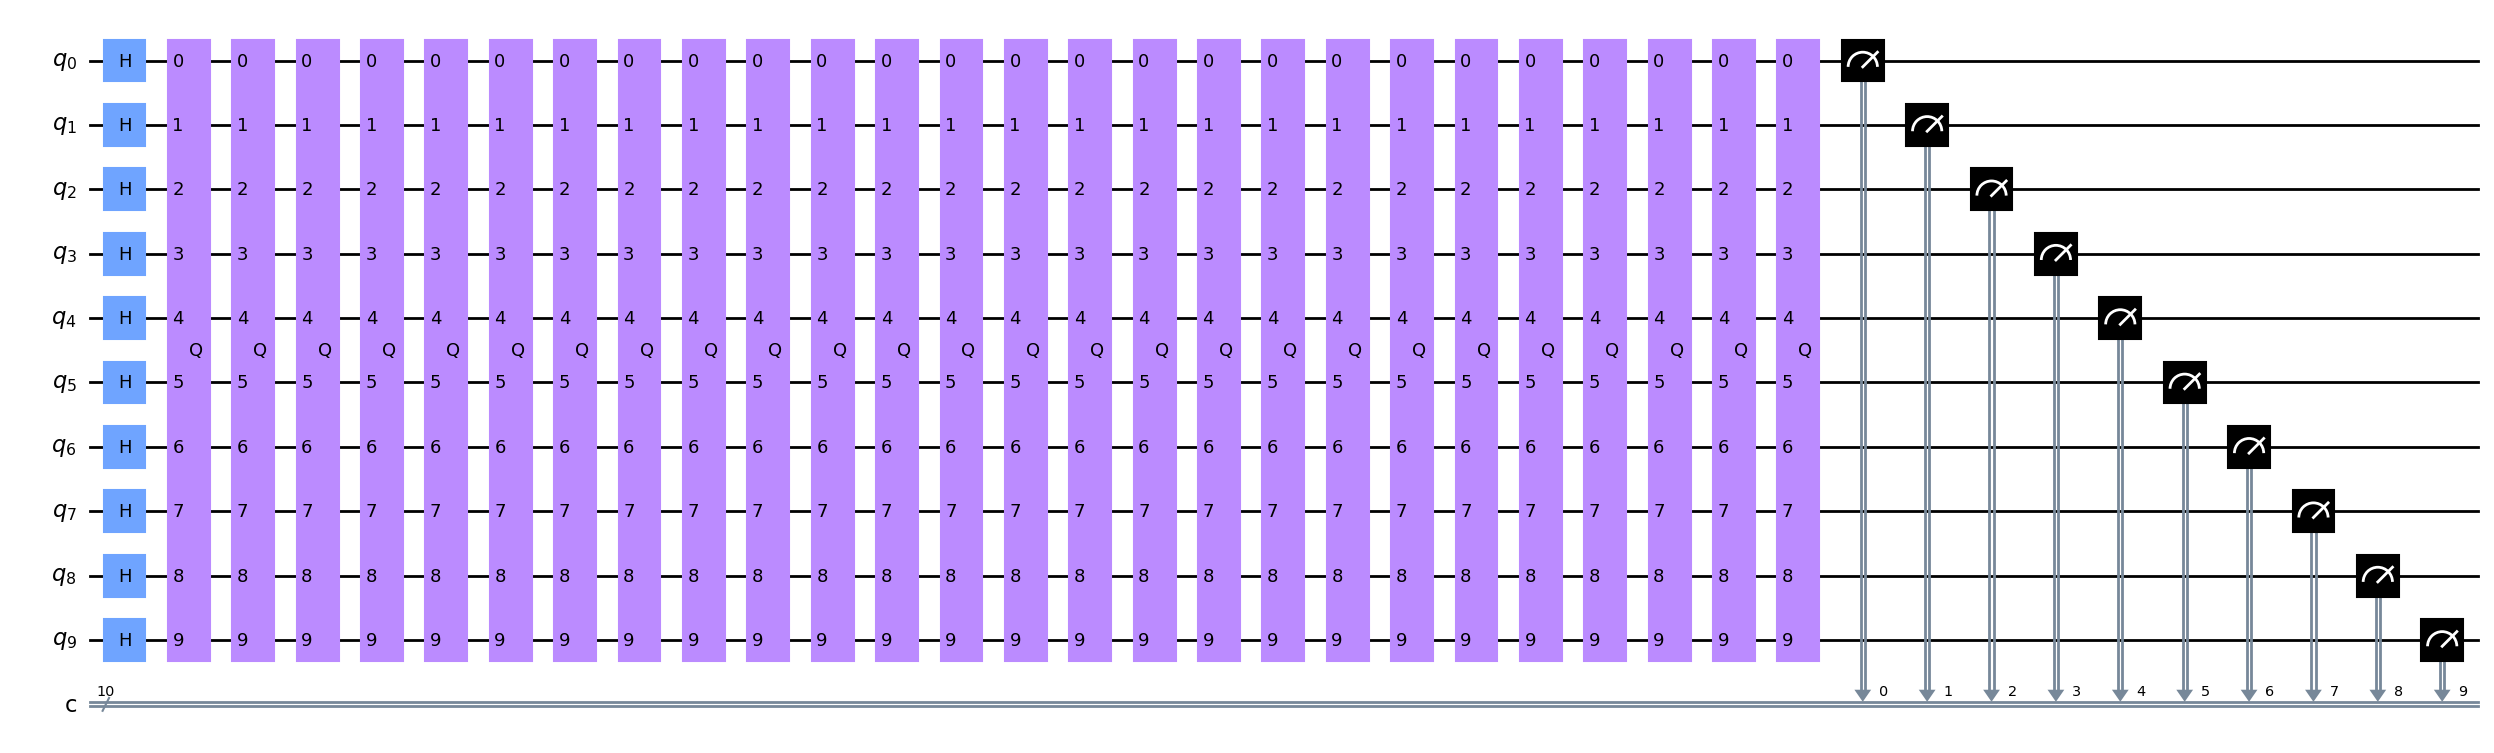

In [16]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph():
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    G.add_weighted_edges_from([
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
])
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    print("iterations:",iterations)
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    for bitstring, count in sorted_counts[:5]:  # Top 5 results
        path = [i for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def main():
    # Create a graph
    G = create_graph()
    
    # Choose start and end nodes
    start = 0
    end = 7
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()

- However, for small weighted graph example, Grover's approach generated the correct smallest path

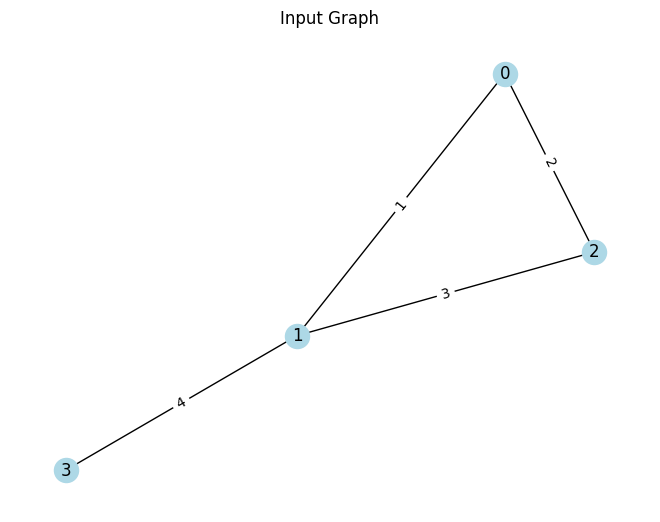

Measurement results:
{'0100': 47, '1101': 495, '0000': 33, '1100': 34, '0010': 32, '1011': 48, '0110': 40, '1110': 23, '0111': 34, '1000': 45, '1001': 38, '1111': 17, '0001': 34, '0011': 40, '0101': 36, '1010': 28}


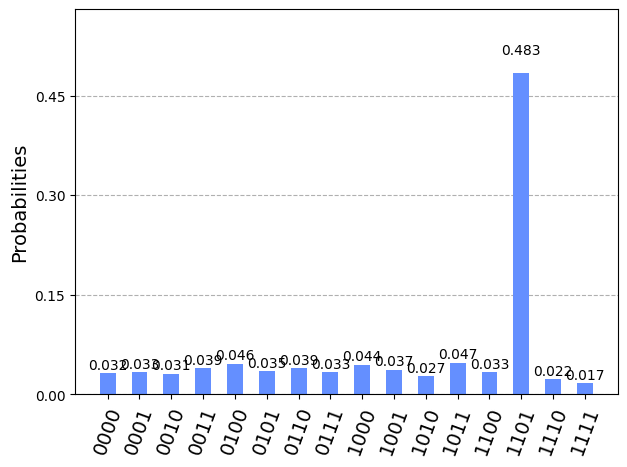


Found shortest paths:
Path: [0, 1, 3], Length: 5


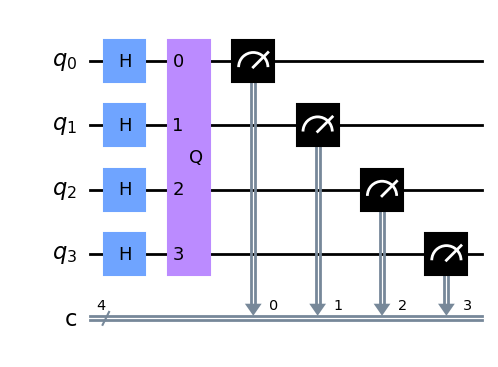

In [12]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph():
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3])
    G.add_weighted_edges_from([(0, 1, 1), (0, 2, 2), 
                              (1, 2, 3), (1, 3, 4)])
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    #iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    iterations = 1
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    for bitstring, count in sorted_counts[:5]:  # Top 5 results
        path = [i for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def main():
    # Create a graph
    G = create_graph()
    
    # Choose start and end nodes
    start = 0
    end = 3
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()

 # 4. Testing, Exploration and Code updates

- after a small code update, Grover's approach generated the correct smallest path for the 10 nodes weighted graph:

  replaced: path = [i for i, bit in enumerate(__reversed__(bitstring)) if bit == '1']

  with: path = [i for i, bit in enumerate(bitstring) if bit == '1']

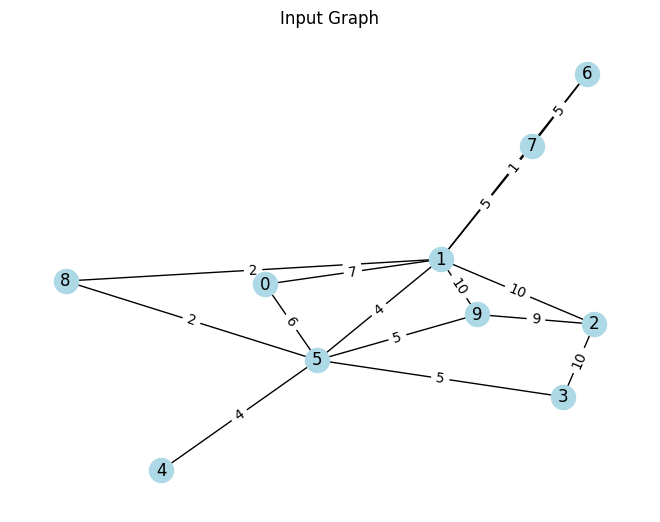

iterations: 26
Measurement results:
{'1100000100': 1014, '1100101001': 1, '1010001010': 1, '1010011000': 1, '0110000000': 1, '1010000000': 1, '1101010000': 1, '0100110101': 1, '1000000110': 1, '1111011101': 1, '1011010100': 1}


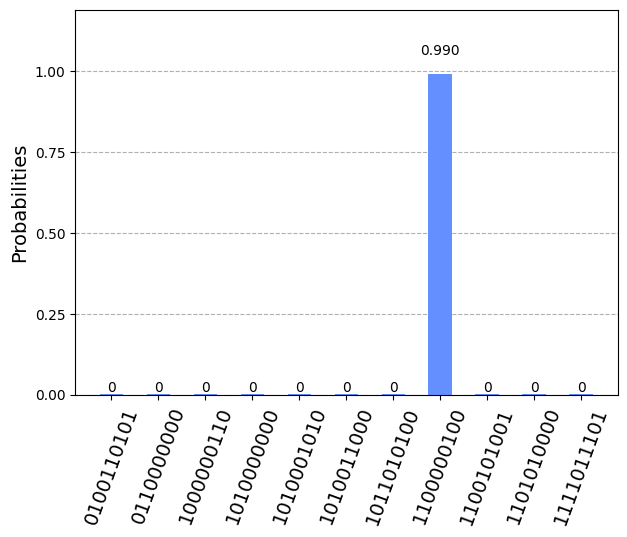

path: [0, 1, 7] start: 0 end: 7
path: [0, 1, 4, 6, 9] start: 0 end: 7
path: [0, 2, 6, 8] start: 0 end: 7
path: [0, 2, 5, 6] start: 0 end: 7
path: [1, 2] start: 0 end: 7

Found shortest paths:
Path: [0, 1, 7], Length: 12


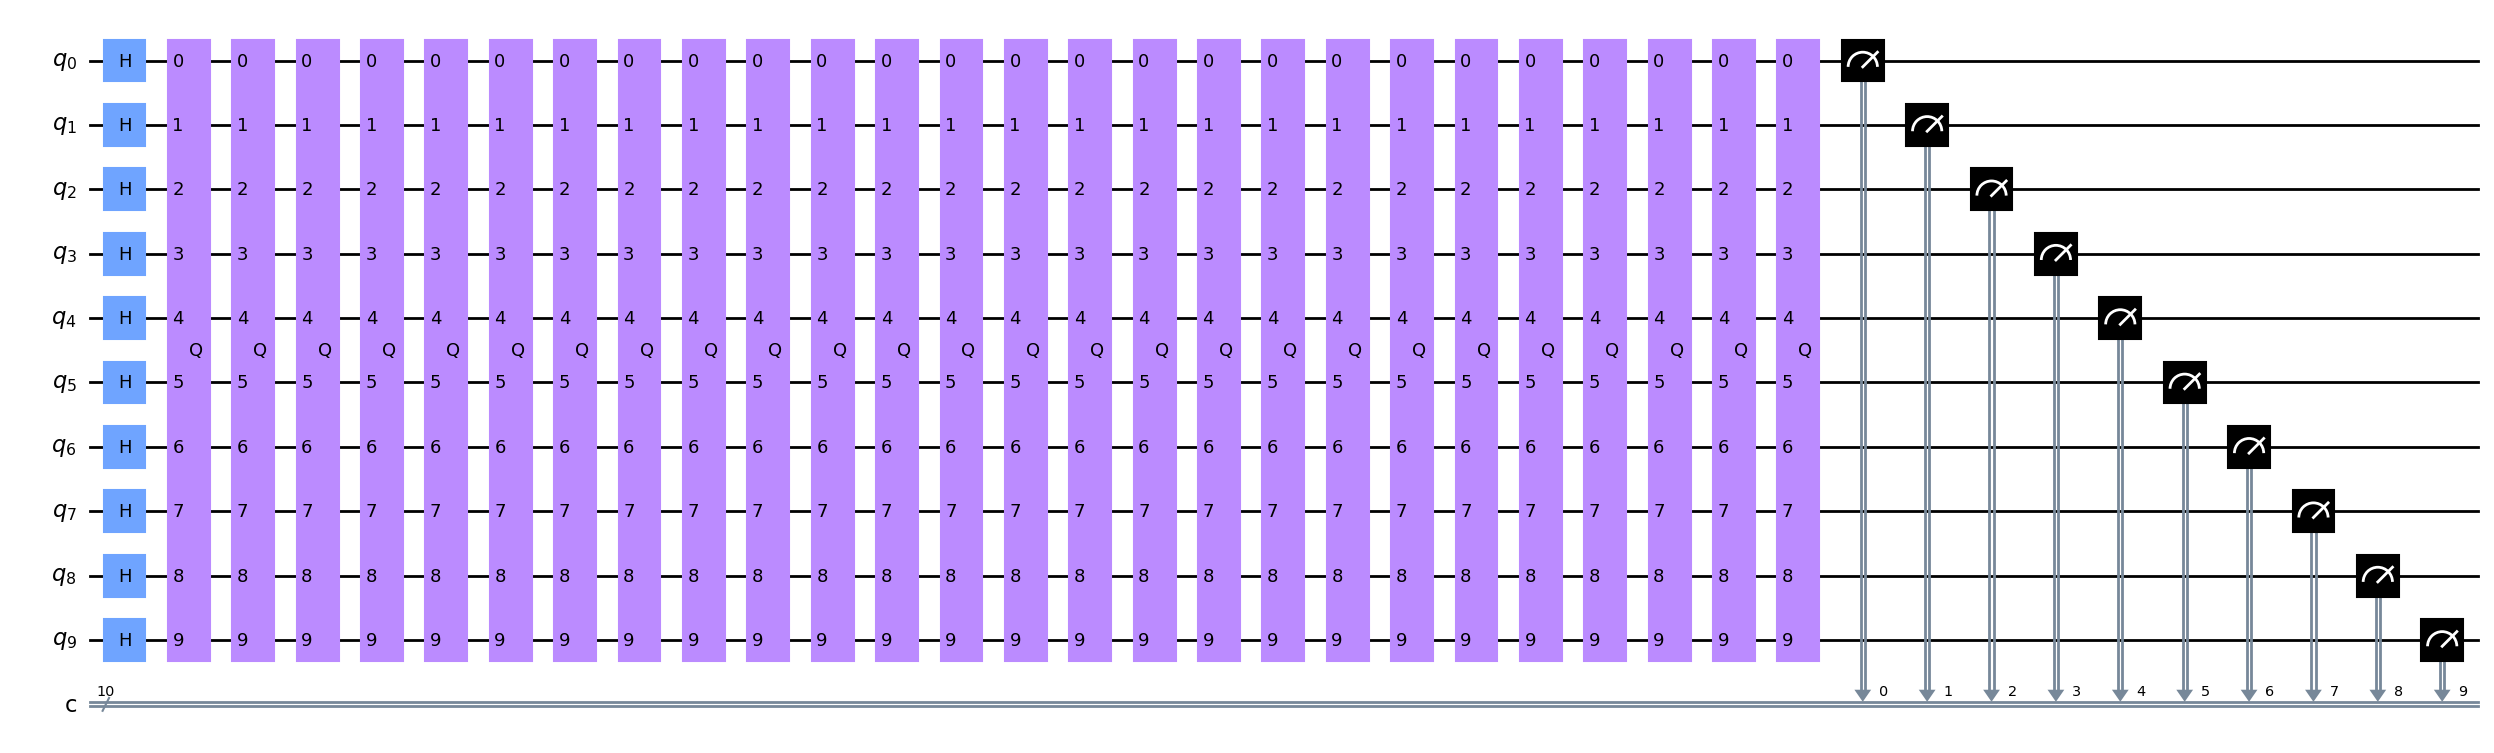

In [11]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph():
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    G.add_weighted_edges_from([
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
])
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    print ("path:",path, "start:",start,"end:",end)
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    print("iterations:",iterations)
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    for bitstring, count in sorted_counts[:5]:  # Top 5 results
        #path = [i for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        path = [i for i, bit in enumerate(bitstring) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def main():
    # Create a graph
    G = create_graph()
    
    # Choose start and end nodes
    start = 0
    end = 7
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()

- Additional correct smallest path examples for both codes

In [4]:
weighted_edges = [
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
]

# Initialize an empty dictionary to store the graph with nodes as strings
graph_dict = {}

# Process each edge to populate the dictionary
for u, v, weight in weighted_edges:
    # Convert nodes to string:
    u_str = str(u)
    v_str = str(v)
    
    # Ensure each node is present in the dictionary
    if u_str not in graph_dict:
        graph_dict[u_str] = {}
    if v_str not in graph_dict:
        graph_dict[v_str] = {}
    
    # Since the graph is undirected, add the edge in both directions
    graph_dict[u_str][v_str] = weight
    graph_dict[v_str][u_str] = weight

# Display the resulting dictionary with string nodes
print("Graph stored as a dictionary with nodes as strings:")
for node, neighbors in graph_dict.items():
    print(f"{node}: {neighbors}")

Graph stored as a dictionary with nodes as strings:
0: {'1': 7, '5': 6}
1: {'0': 7, '2': 10, '5': 4, '6': 1, '7': 5, '8': 2, '9': 10}
5: {'0': 6, '1': 4, '3': 5, '4': 4, '8': 2, '9': 5}
2: {'1': 10, '3': 10, '9': 9}
6: {'1': 1, '7': 5}
7: {'1': 5, '6': 5}
8: {'1': 2, '5': 2}
9: {'1': 10, '2': 9, '5': 5}
3: {'2': 10, '5': 5}
4: {'5': 4}


In [5]:
start_node = '0'
end_node = '9'
path, cost = dijkstra(graph_dict, start_node, end_node)

if path:
    print(f"The shortest path from {start_node} to {end_node} is: {' -> '.join(path)} with a cost of {cost}")
else:
    print(f"No path found from {start_node} to {end_node}")

The shortest path from 0 to 9 is: 0 -> 5 -> 9 with a cost of 11


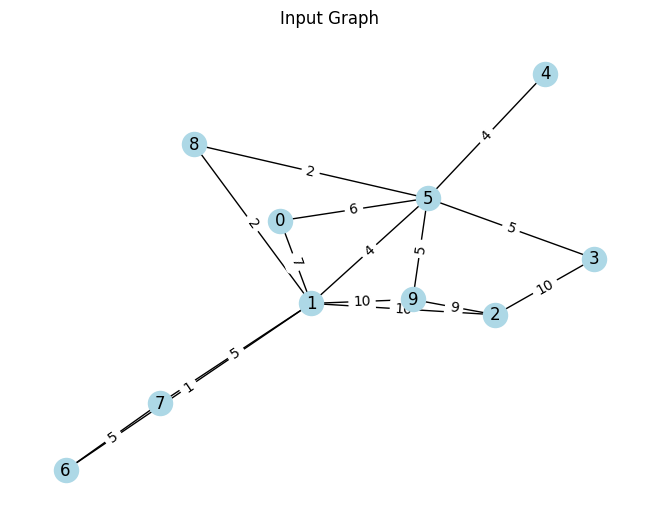

iterations: 26
Measurement results:
{'1000010001': 1019, '0110111001': 1, '0000000010': 1, '1010001111': 1, '0001001011': 1, '0101111010': 1}


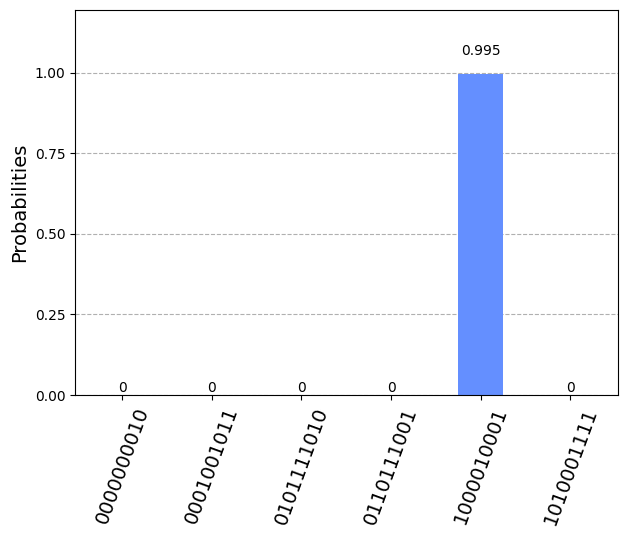

path: [0, 5, 9] start: 0 end: 9
path: [1, 2, 4, 5, 6, 9] start: 0 end: 9
path: [8] start: 0 end: 9
path: [0, 2, 6, 7, 8, 9] start: 0 end: 9
path: [3, 6, 8, 9] start: 0 end: 9

Found shortest paths:
Path: [0, 5, 9], Length: 11


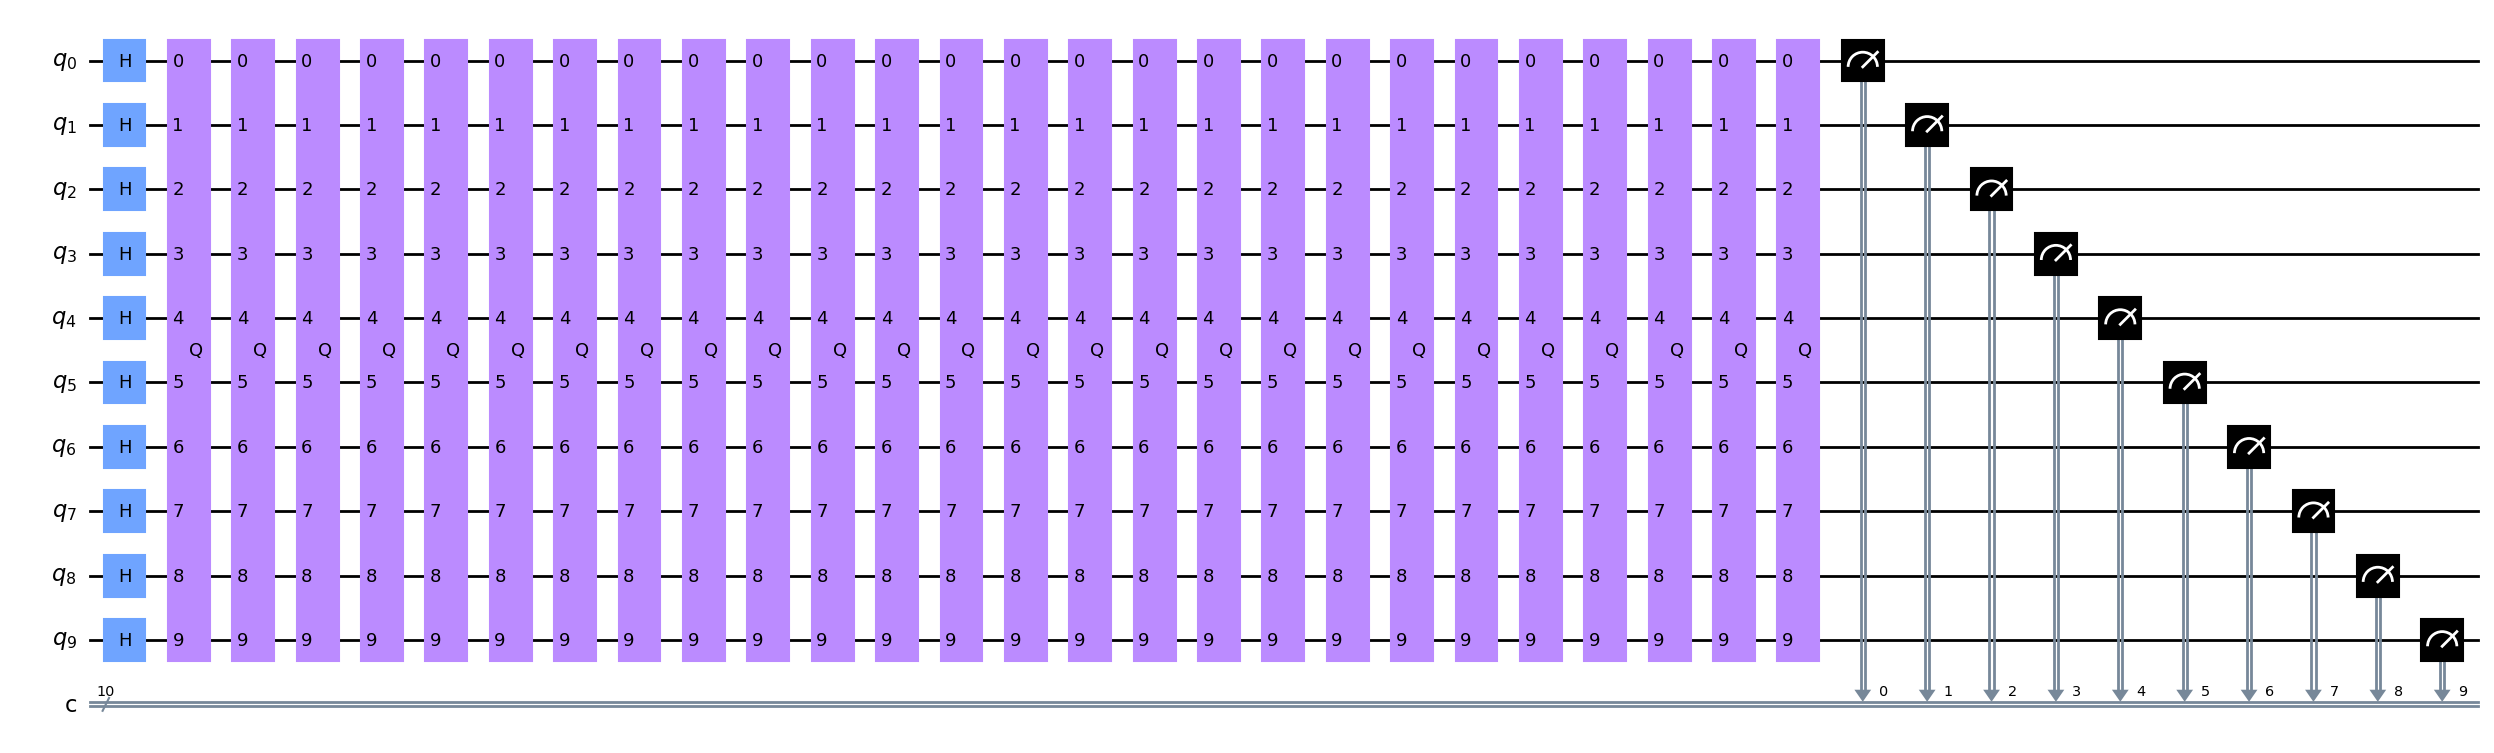

In [16]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph():
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    G.add_weighted_edges_from([
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
])
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    print ("path:",path, "start:",start,"end:",end)
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    print("iterations:",iterations)
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    for bitstring, count in sorted_counts[:5]:  # Top 5 results
        #path = [i for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        path = [i for i, bit in enumerate(bitstring) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def main():
    # Create a graph
    G = create_graph()
    
    # Choose start and end nodes
    start = 0
    end = 9
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()

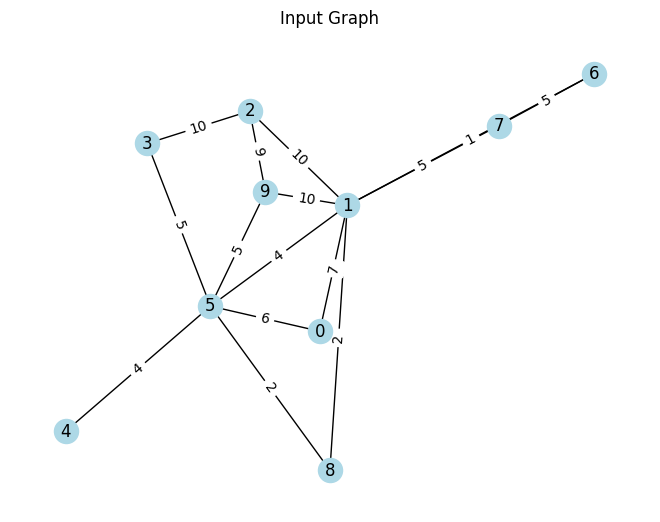

Starting parameter tuning...


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\quantum_instance.py:135: DeprecationWarning: The class qiskit.aqua.QuantumInstance is deprecated. It was moved/refactored to qiskit.utils.QuantumInstance (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_class('aqua.QuantumInstance',
C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\components\optimizers\optimizer.py:49: DeprecationWarning: The package qiskit.aqua.components.optimizers is deprecated. It was moved/refactored to qiskit.algorithms.optimizers (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('aqua.components.optimizers',


Optimization results:
Best θ: 2.7003
Best γ: -0.1367
Best score: 0.0039

Running with tuned parameters...

Top solutions:
1. Path: [0, 5, 9], Length: 11, Count: 28
2. Path: [0, 1, 5, 9], Length: 16, Count: 2
3. Path: [0, 1, 9], Length: 17, Count: 23

Final circuit:


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\tools\pi_check.py:49: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  if not hasattr(inpt._symbol_expr, "expr_free_symbols"):


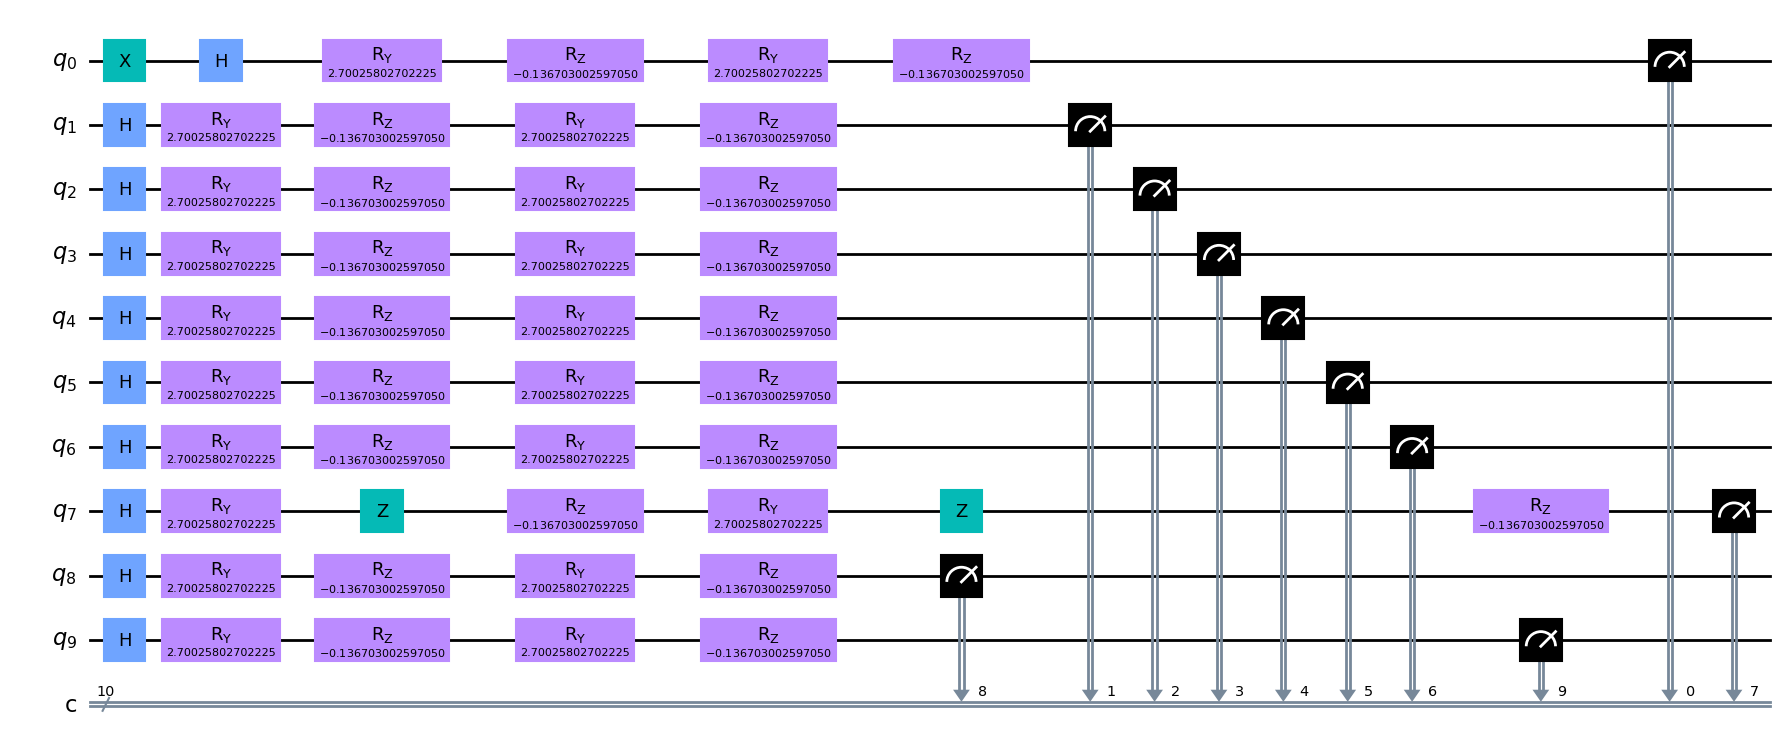

In [18]:
# Define the list of weighted edges (nodes are provided as integers)
weighted_edges = [
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
]

G = nx.Graph()
G.add_weighted_edges_from(weighted_edges)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Input Graph")
plt.show()

run_example(G, 0, 9)

In [23]:
start_node = '0'
end_node = '8'
path, cost = dijkstra(graph_dict, start_node, end_node)

if path:
    print(f"The shortest path from {start_node} to {end_node} is: {' -> '.join(path)} with a cost of {cost}")
else:
    print(f"No path found from {start_node} to {end_node}")

The shortest path from 0 to 8 is: 0 -> 5 -> 8 with a cost of 8


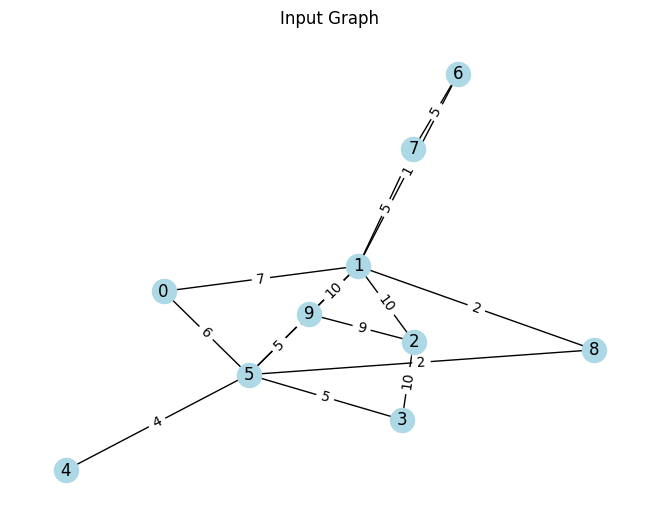

iterations: 26
Measurement results:
{'1000010010': 1011, '0100001010': 1, '0111001000': 1, '1110110111': 1, '0111001011': 1, '0111111010': 1, '0011011011': 1, '1011101011': 1, '1001000001': 1, '0101110010': 1, '0010000000': 1, '0010000100': 1, '0001101110': 1, '1001110111': 1}


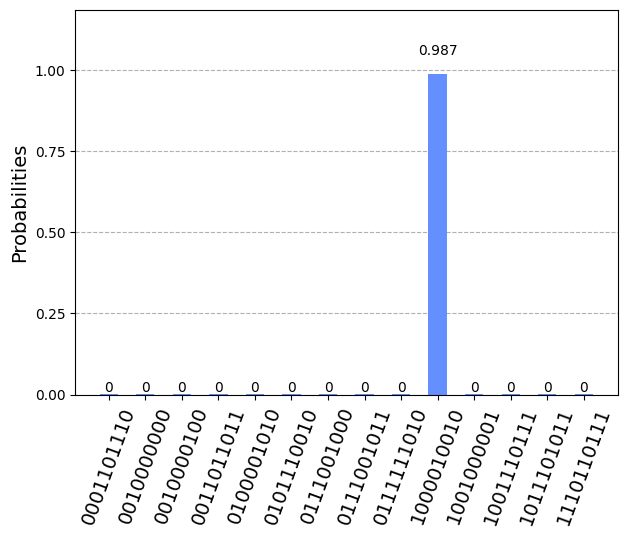

path: [0, 5, 8] start: 0 end: 8
path: [1, 6, 8] start: 0 end: 8
path: [1, 2, 3, 6] start: 0 end: 8
path: [0, 1, 2, 4, 5, 7, 8, 9] start: 0 end: 8
path: [1, 2, 3, 6, 8, 9] start: 0 end: 8

Found shortest paths:
Path: [0, 5, 8], Length: 8


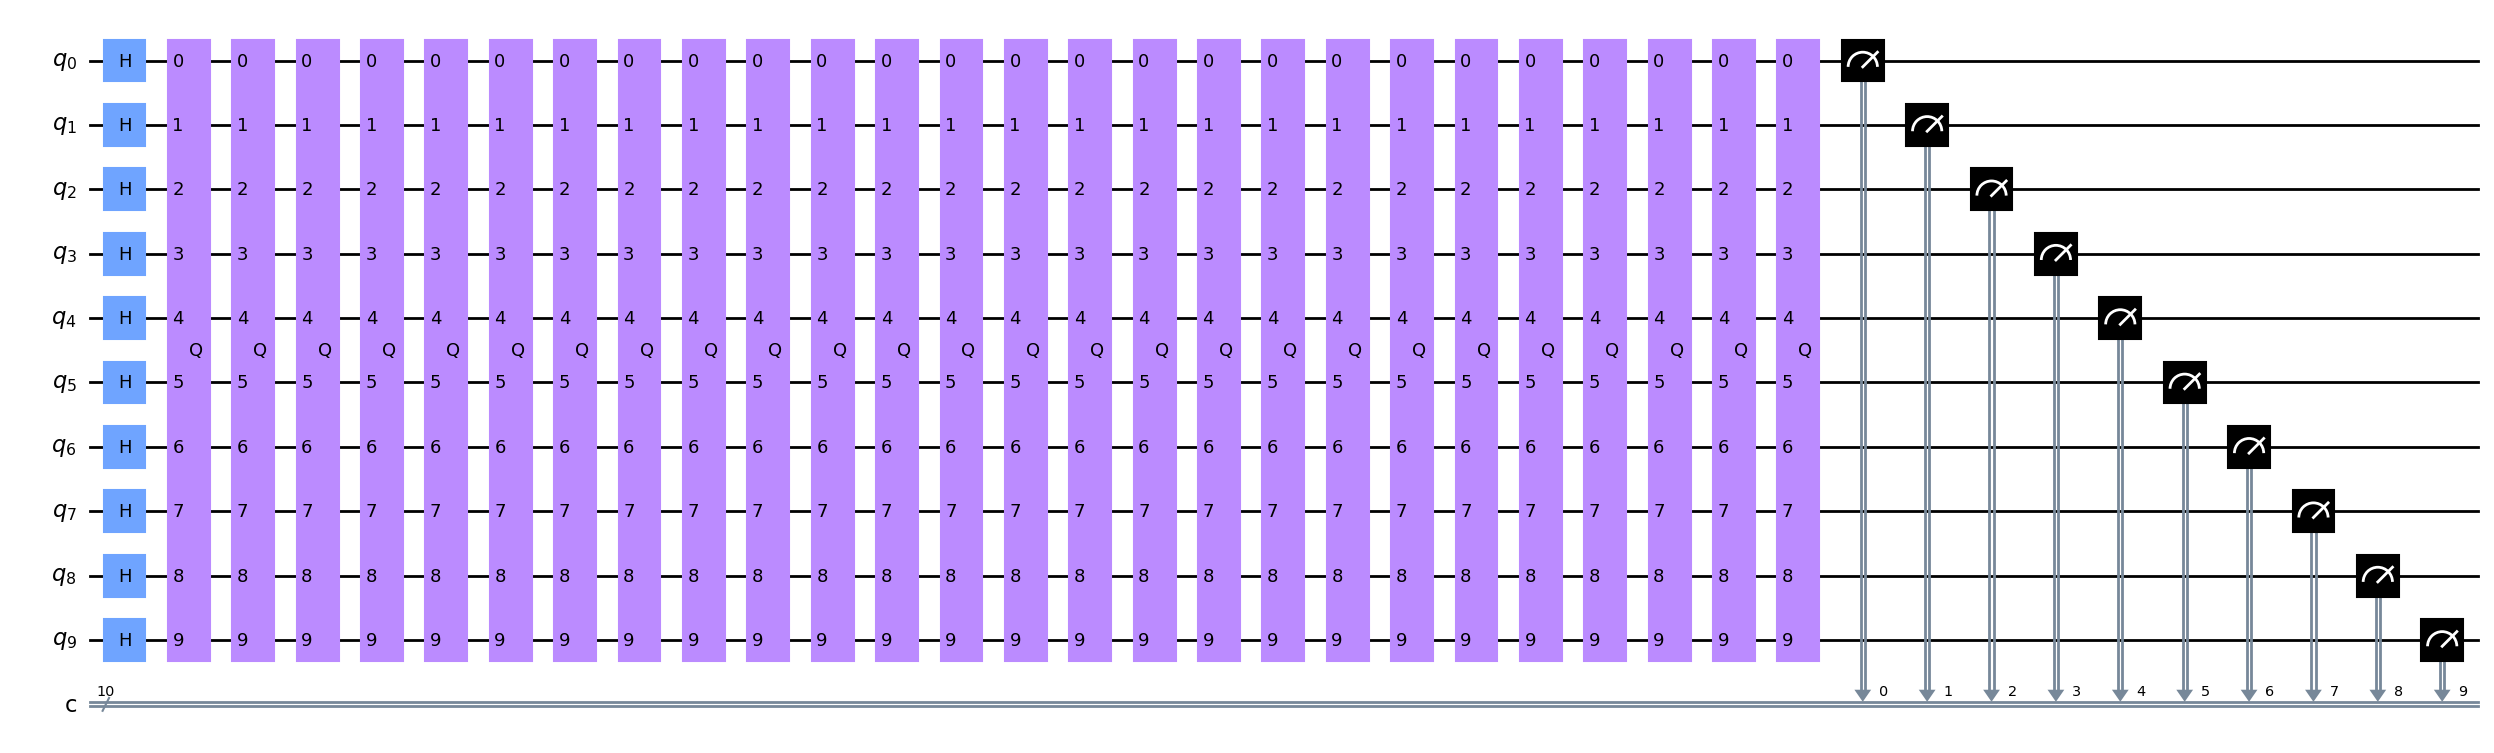

In [24]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph():
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    G.add_weighted_edges_from([
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
])
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    print ("path:",path, "start:",start,"end:",end)
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    print("iterations:",iterations)
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    for bitstring, count in sorted_counts[:5]:  # Top 5 results
        #path = [i for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        path = [i for i, bit in enumerate(bitstring) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def main():
    # Create a graph
    G = create_graph()
    
    # Choose start and end nodes
    start = 0
    end = 8
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()

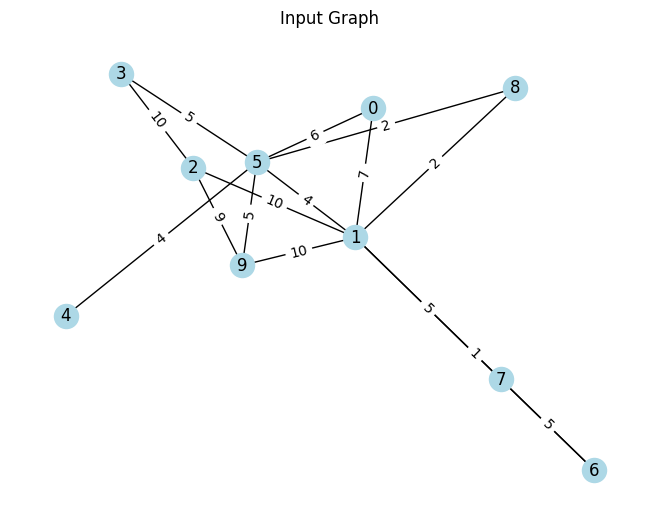

Starting parameter tuning...
Optimization results:
Best θ: 2.7193
Best γ: 0.0455
Best score: 0.0051

Running with tuned parameters...

Top solutions:
1. Path: [0, 5, 8], Length: 8, Count: 22
2. Path: [0, 1, 8], Length: 9, Count: 24
3. Path: [0, 1, 5, 8], Length: 13, Count: 2

Final circuit:


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\tools\pi_check.py:49: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  if not hasattr(inpt._symbol_expr, "expr_free_symbols"):


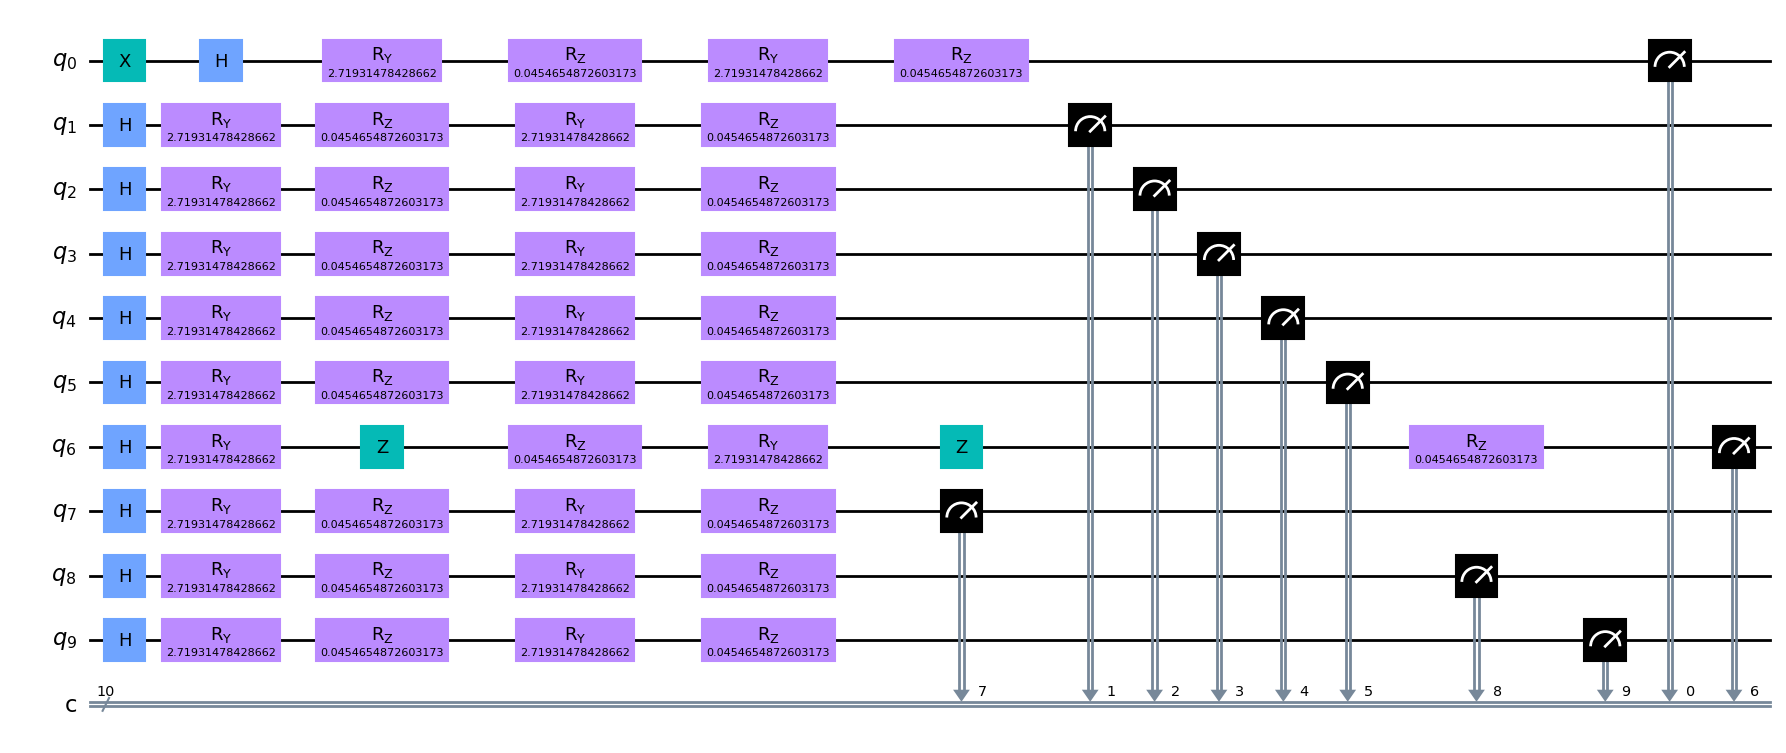

In [25]:
# Define the list of weighted edges (nodes are provided as integers)
weighted_edges = [
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
]

G = nx.Graph()
G.add_weighted_edges_from(weighted_edges)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Input Graph")
plt.show()

run_example(G, 0, 8)

In [19]:
start_node = '1'
end_node = '9'
path, cost = dijkstra(graph_dict, start_node, end_node)

if path:
    print(f"The shortest path from {start_node} to {end_node} is: {' -> '.join(path)} with a cost of {cost}")
else:
    print(f"No path found from {start_node} to {end_node}")

The shortest path from 1 to 9 is: 1 -> 5 -> 9 with a cost of 9


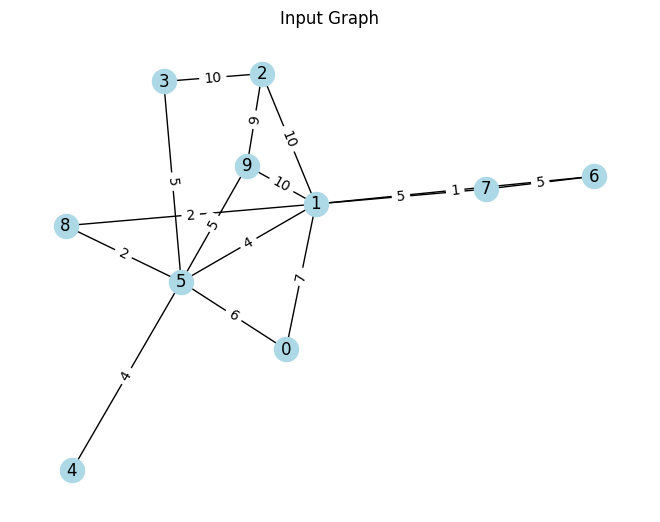

iterations: 18
Measurement results:
{'0011100110': 1, '0100010001': 491, '0100010011': 530, '0000101000': 1, '1110101111': 1}


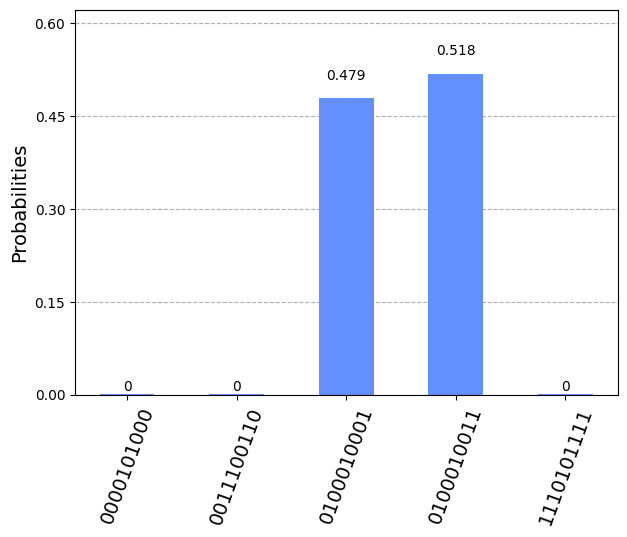

path: [1, 5, 8, 9] start: 1 end: 9
path: [1, 5, 9] start: 1 end: 9
path: [2, 3, 4, 7, 8] start: 1 end: 9
path: [4, 6] start: 1 end: 9
path: [0, 1, 2, 4, 6, 7, 8, 9] start: 1 end: 9

Found shortest paths:
Path: [1, 5, 9], Length: 9


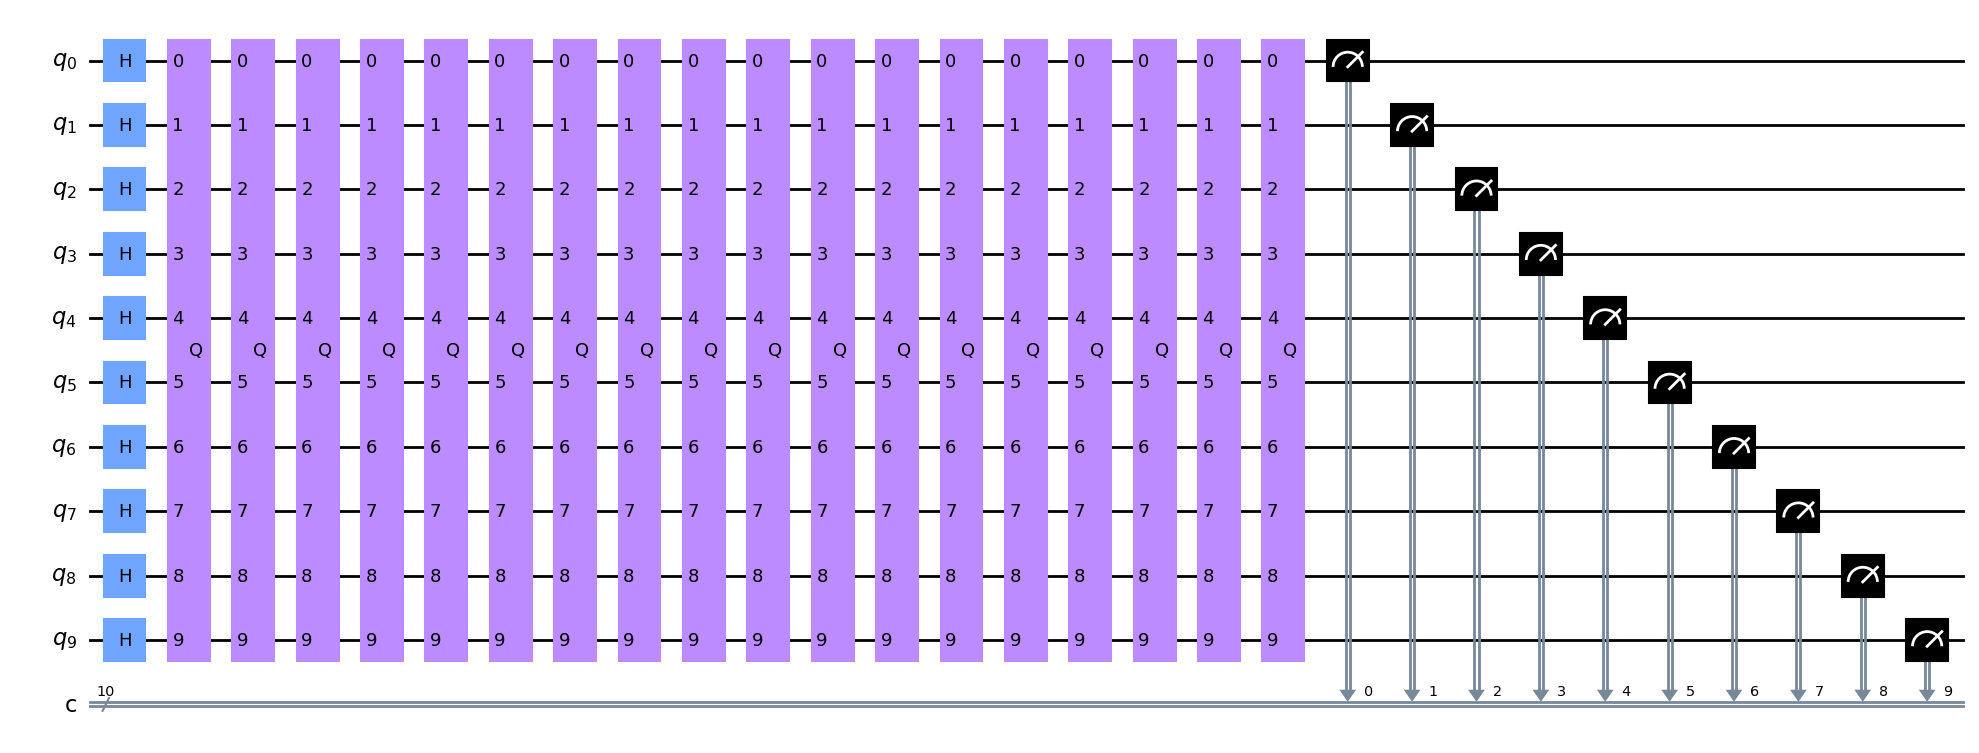

In [7]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph():
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    G.add_weighted_edges_from([
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
])
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    print ("path:",path, "start:",start,"end:",end)
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    print("iterations:",iterations)
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    for bitstring, count in sorted_counts[:5]:  # Top 5 results
        path = [i for i, bit in enumerate(bitstring) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def main():
    # Create a graph
    G = create_graph()
    
    # Choose start and end nodes
    start = 1
    end = 9
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()

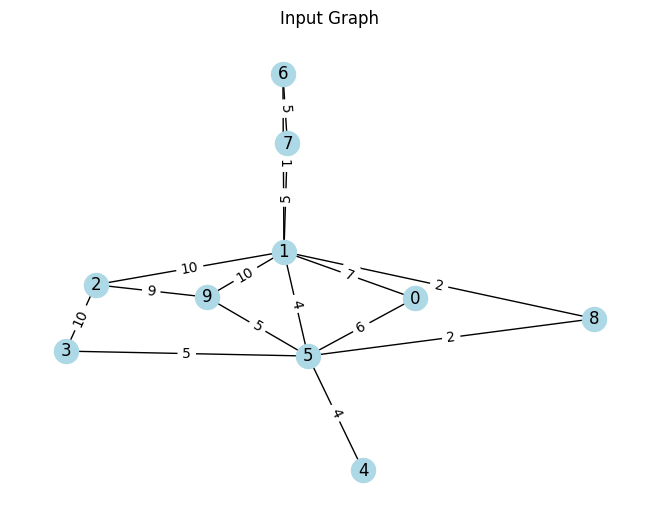

Starting parameter tuning...


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\quantum_instance.py:135: DeprecationWarning: The class qiskit.aqua.QuantumInstance is deprecated. It was moved/refactored to qiskit.utils.QuantumInstance (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_class('aqua.QuantumInstance',
C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\components\optimizers\optimizer.py:49: DeprecationWarning: The package qiskit.aqua.components.optimizers is deprecated. It was moved/refactored to qiskit.algorithms.optimizers (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('aqua.components.optimizers',


Optimization results:
Best θ: 2.3302
Best γ: -0.2035
Best score: 0.0451

Running with tuned parameters...

Top solutions:
1. Path: [1, 5, 9], Length: 9, Count: 2
2. Path: [1, 9], Length: 10, Count: 490
3. Path: [1, 2, 9], Length: 19, Count: 1

Final circuit:


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\tools\pi_check.py:49: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  if not hasattr(inpt._symbol_expr, "expr_free_symbols"):


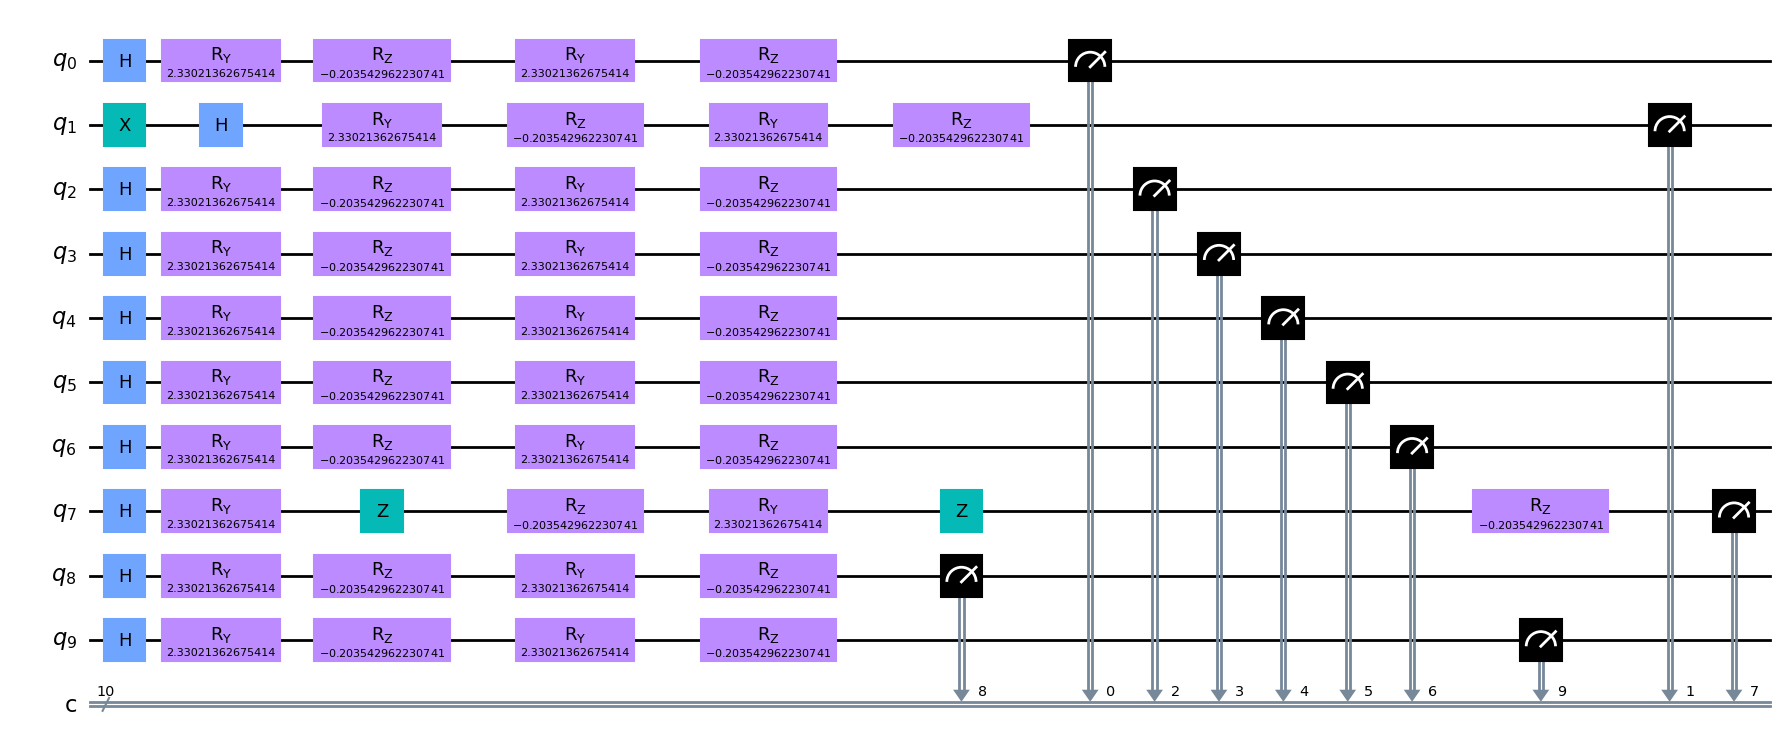

In [8]:
# Define the list of weighted edges (nodes are provided as integers)
weighted_edges = [
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
]

G = nx.Graph()
G.add_weighted_edges_from(weighted_edges)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Input Graph")
plt.show()

run_example(G, 1, 9)

# 5. Parameter space exploration

Starting parameter tuning...


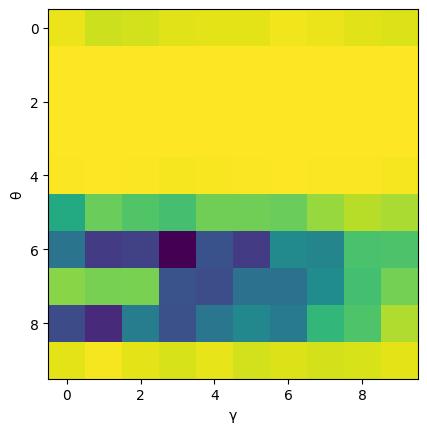

In [16]:
def run_test(G,start,end):
    # Initialize solver
    solver = QuantumShortestPathSolver(G, start, end)
    
    # Run parameter tuning
    print("Starting parameter tuning...")
    tuner = ParameterTuner(solver, shots=2048) #shots=512
    thetas = np.linspace(0, np.pi, 10)
    gammas = np.linspace(0, np.pi/2, 10)
    scores = np.zeros((10, 10))
    for i, theta in enumerate(thetas):
        for j, gamma in enumerate(gammas):         
            scores[i,j] = tuner.objective_function([theta, gamma])
            #print(f"scores[{i},{j}]: {scores[i,j]}")
    plt.imshow(scores); plt.xlabel('γ'); plt.ylabel('θ')

run_test(G, 0, 8)    

- getting best gamma and theta for a range of input gamma and theta values

Starting parameter tuning...
Optimization results:
Best θ: 0.0000
Best γ: 0.0000
Best score: -0.0000
theta: 0.0 gamma: 0.0 scores[0,0]: 0.0 best_theta: 0.0 best_gamma: 0.0
Optimization results:
Best θ: 0.0000
Best γ: 0.1745
Best score: -0.0000
theta: 0.0 gamma: 0.17453292519943295 scores[0,1]: 0.0 best_theta: 0.0 best_gamma: 0.1745
Optimization results:
Best θ: 0.0000
Best γ: 0.3491
Best score: -0.0000
theta: 0.0 gamma: 0.3490658503988659 scores[0,2]: 0.0 best_theta: 0.0 best_gamma: 0.3491
Optimization results:
Best θ: 0.0000
Best γ: 0.5236
Best score: -0.0000
theta: 0.0 gamma: 0.5235987755982988 scores[0,3]: 0.0 best_theta: 0.0 best_gamma: 0.5236
Optimization results:
Best θ: 0.0000
Best γ: 0.6981
Best score: -0.0000
theta: 0.0 gamma: 0.6981317007977318 scores[0,4]: 0.0 best_theta: 0.0 best_gamma: 0.6981
Optimization results:
Best θ: 0.0000
Best γ: 0.8727
Best score: -0.0000
theta: 0.0 gamma: 0.8726646259971648 scores[0,5]: 0.0 best_theta: 0.0 best_gamma: 0.8727
Optimization results:


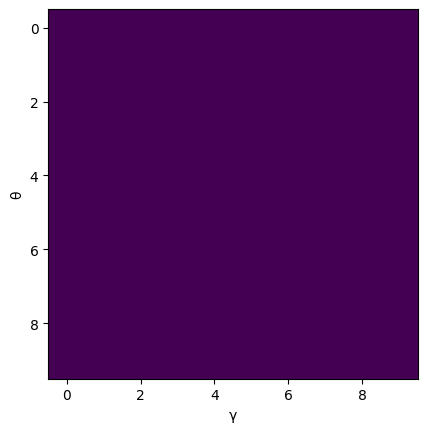

In [17]:
import math

def run_test(G,start,end):
    # Initialize solver
    solver = QuantumShortestPathSolver(G, start, end)
    
    # Run parameter tuning
    print("Starting parameter tuning...")
    tuner = ParameterTuner(solver, shots=2048) #shots=512
    thetas = np.linspace(0, np.pi, 10)
    gammas = np.linspace(0, np.pi/2, 10)
    scores = np.zeros((10, 10))
    max_score = -math.inf
    max_theta = -math.inf
    max_gamma = -math.inf
    for i, theta in enumerate(thetas):
        for j, gamma in enumerate(gammas):         
            scores[i,j] = tuner.objective_function([theta, gamma])
            if scores[i,j] > max_score:
                max_score = scores[i,j]
            best_theta, best_gamma = tuner.tune_parameters([theta, gamma],maxiter=60) #maxiter=15
            best_theta = round(best_theta,4)
            best_gamma = round(best_gamma,4)
            if best_theta > max_theta:
                max_theta = best_theta
            if best_gamma > max_gamma:
                max_gamma = best_gamma
            print(f"theta: {theta} gamma: {gamma} scores[{i},{j}]: {scores[i,j]} best_theta: {best_theta} best_gamma: {best_gamma}")
    print("max_score:",max_score, "max_theta:", max_theta, "max_gamma:", max_gamma)
    plt.imshow(scores); plt.xlabel('γ'); plt.ylabel('θ')

run_test(G, 3, 9)   

# 6. Final Code

__GroverGraphShortestPath__

In [4]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, pi

def create_graph(vertices, weighted_edges):
    """Create a sample graph for testing"""
    G = nx.Graph()
    G.add_nodes_from(vertices)
    G.add_weighted_edges_from(weighted_edges)
    return G

def path_to_bitstring(path, num_nodes):
    """Convert a path to a bitstring representation"""
    bitstring = ['0'] * num_nodes
    for node in path:
        bitstring[node] = '1'
    return ''.join(bitstring)

def is_valid_path(G, path, start, end):
    """Check if the path is valid (connects start to end through edges)"""
    print ("path:",path, "start:",start,"end:",end)
    if not path or path[0] != start or path[-1] != end:
        return False
    for i in range(len(path)-1):
        if not G.has_edge(path[i], path[i+1]):
            return False
    return True

def create_oracle(G, start, end, num_nodes):
    """Create an oracle that marks valid paths from start to end"""
    # Generate all possible paths (for small graphs)
    all_paths = []
    for path in nx.all_simple_paths(G, start, end):
        all_paths.append(path)
    
    # Find the minimal path length
    if not all_paths:
        raise ValueError("No paths exist between the specified nodes")
    
    min_length = min(sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1)) for path in all_paths)
    
    # Mark states that represent valid paths with minimal length
    marked_states = []
    for path in all_paths:
        path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
        if path_length == min_length:
            bitstring = path_to_bitstring(path, num_nodes)
            marked_states.append(bitstring)
    
    # Create oracle circuit
    oracle = QuantumCircuit(num_nodes)
    for state in marked_states:
        # Flip the phase of marked states
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
        oracle.h(num_nodes-1)
        oracle.mcx(list(range(num_nodes-1)), num_nodes-1)
        oracle.h(num_nodes-1)
        oracle.x([i for i, bit in enumerate(reversed(state)) if bit == '0'])
    
    return oracle, len(marked_states)

def grover_shortest_path(G, start, end):
    """Find shortest path using Grover's algorithm"""
    num_nodes = len(G.nodes)
    
    # Create oracle
    oracle, num_solutions = create_oracle(G, start, end, num_nodes)
    
    # Determine optimal number of Grover iterations
    iterations = ceil(pi/4 * np.sqrt(2**num_nodes / num_solutions))
    print("iterations:",iterations)
    
    # Create Grover operator
    grover_operator = GroverOperator(oracle)
    
    # Construct the full circuit
    qc = QuantumCircuit(num_nodes, num_nodes)
    qc.h(range(num_nodes))  # Apply Hadamard to all qubits
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.append(grover_operator, range(num_nodes))
    
    # Measure all qubits
    qc.measure(range(num_nodes), range(num_nodes))
    
    # Execute the circuit
    backend = Aer.get_backend('qasm_simulator')
    shots = 1024
    result = execute(qc, backend, shots=shots).result()
    counts = result.get_counts()
    
    # Display results
    print("Measurement results:")
    print(counts)
    plot_histogram(counts)
    plt.show()

    qc.draw(output='mpl', fold=100)
    
    # Find the most probable solutions
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    # Interpret results
    solutions = []
    #for bitstring, count in sorted_counts[:5]:  # Top 5 results
    for bitstring, count in sorted_counts:  # All results
        path = [i for i, bit in enumerate(bitstring) if bit == '1']
        if is_valid_path(G, path, start, end):
            path_length = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            solutions.append((path, path_length))
    
    # Remove duplicates
    unique_solutions = []
    seen = set()
    for solution in solutions:
        path_str = str(solution[0])
        if path_str not in seen:
            seen.add(path_str)
            unique_solutions.append(solution)
    
    return unique_solutions

def run_GroverGraphShortestPath(G, start, end):
    # Choose start and end nodes
    start = start
    end = end
    
    # Draw the graph
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Input Graph")
    plt.show()
    
    # Find shortest path using Grover's algorithm
    solutions = grover_shortest_path(G, start, end)
    
    if solutions:
        print("\nFound shortest paths:")
        for path, length in solutions:
            print(f"Path: {path}, Length: {length}")
    else:
        print("No valid path found.")

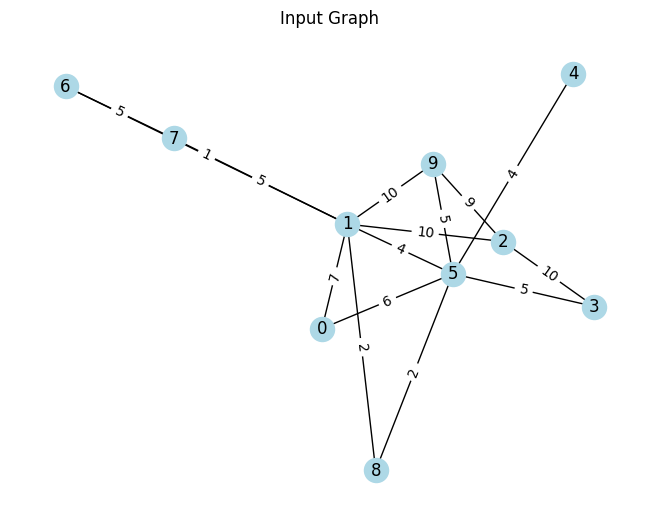

iterations: 18
Measurement results:
{'1110000010': 1, '0100011100': 1, '0100010011': 510, '0100010001': 507, '1000101110': 1, '0010011101': 1, '1000001101': 1, '1010110010': 1, '0010001110': 1}


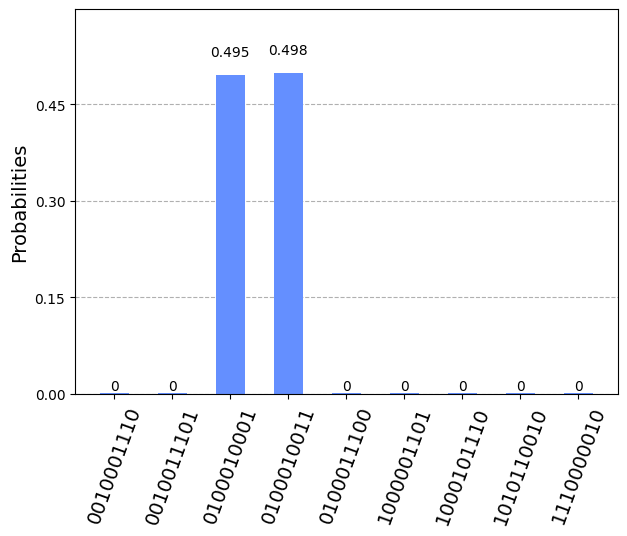

path: [1, 5, 8, 9] start: 1 end: 9
path: [1, 5, 9] start: 1 end: 9
path: [0, 1, 2, 8] start: 1 end: 9
path: [1, 5, 6, 7] start: 1 end: 9
path: [0, 4, 6, 7, 8] start: 1 end: 9
path: [2, 5, 6, 7, 9] start: 1 end: 9
path: [0, 6, 7, 9] start: 1 end: 9
path: [0, 2, 4, 5, 8] start: 1 end: 9
path: [2, 6, 7, 8] start: 1 end: 9

Found shortest paths:
Path: [1, 5, 9], Length: 9


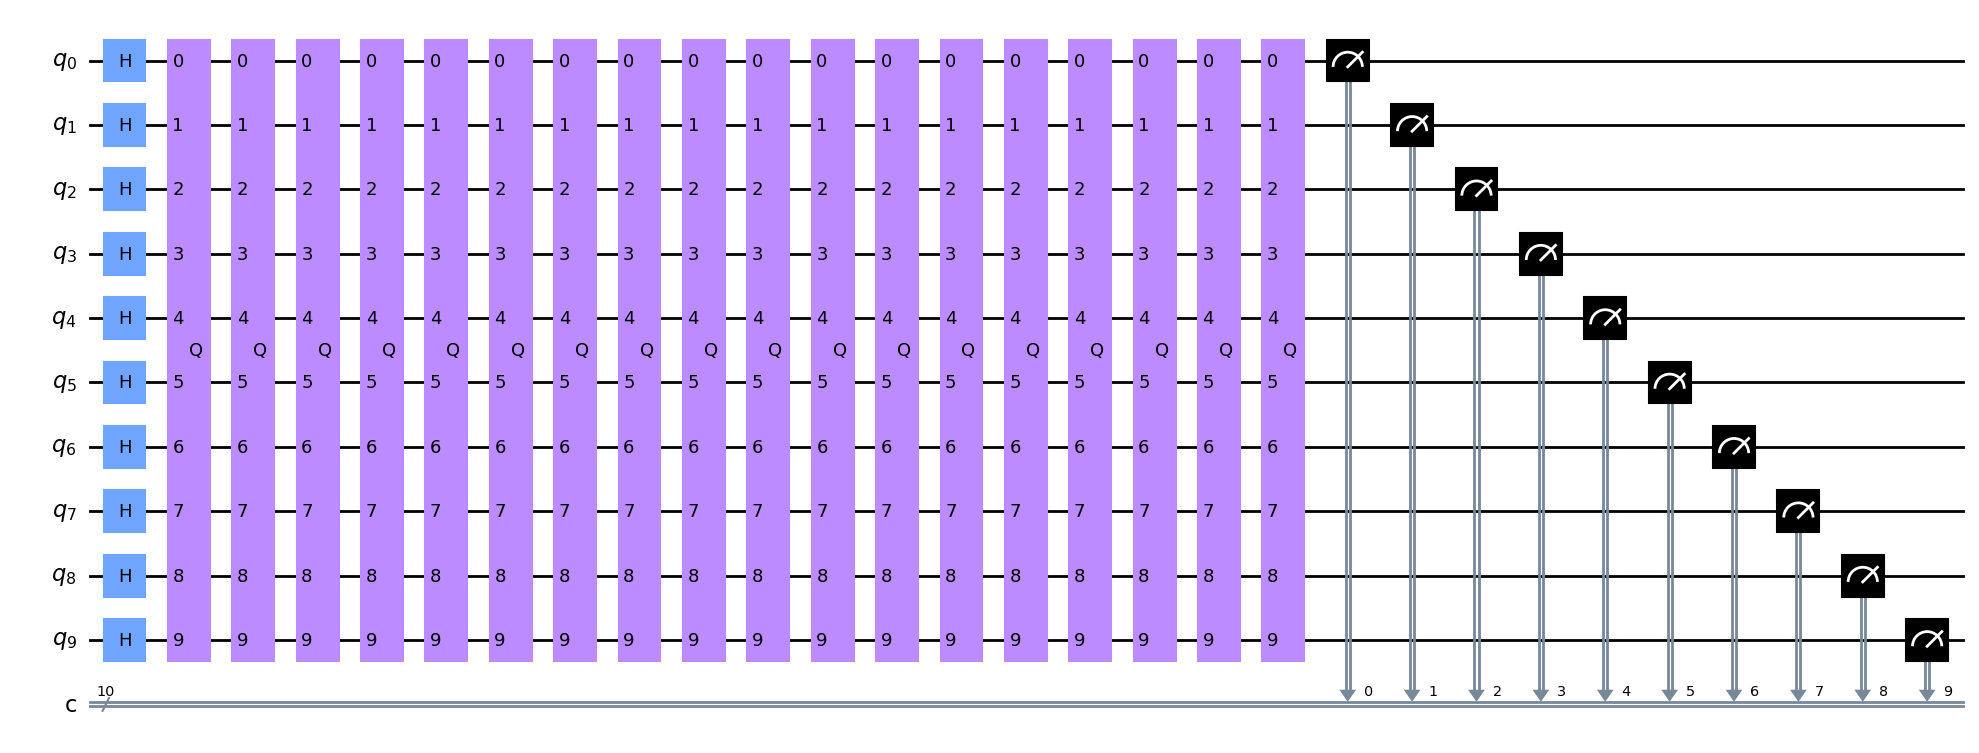

In [16]:
vertices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
weighted_edges = [
    (0, 1, 7),
    (0, 5, 6),
    (1, 2, 10),
    (1, 5, 4),
    (1, 6, 1),
    (1, 7, 5),
    (1, 8, 2),
    (1, 9, 10),
    (2, 3, 10),
    (2, 9, 9),
    (3, 5, 5),
    (4, 5, 4),
    (5, 8, 2),
    (5, 9, 5),
    (6, 7, 5)
]

G = create_graph(vertices,weighted_edges) 
run_GroverGraphShortestPath(G, 1, 9)

- classical solution

In [11]:
# Initialize an empty dictionary to store the graph with nodes as strings
graph_dict = {}

# Process each edge to populate the dictionary
for u, v, weight in weighted_edges:
    # Convert nodes to string:
    u_str = str(u)
    v_str = str(v)
    
    # Ensure each node is present in the dictionary
    if u_str not in graph_dict:
        graph_dict[u_str] = {}
    if v_str not in graph_dict:
        graph_dict[v_str] = {}
    
    # Since the graph is undirected, add the edge in both directions
    graph_dict[u_str][v_str] = weight
    graph_dict[v_str][u_str] = weight

# Display the resulting dictionary with string nodes
print("Graph stored as a dictionary with nodes as strings:")
for node, neighbors in graph_dict.items():
    print(f"{node}: {neighbors}")

Graph stored as a dictionary with nodes as strings:
0: {'1': 7, '5': 6}
1: {'0': 7, '2': 10, '5': 4, '6': 1, '7': 5, '8': 2, '9': 10}
5: {'0': 6, '1': 4, '3': 5, '4': 4, '8': 2, '9': 5}
2: {'1': 10, '3': 10, '9': 9}
6: {'1': 1, '7': 5}
7: {'1': 5, '6': 5}
8: {'1': 2, '5': 2}
9: {'1': 10, '2': 9, '5': 5}
3: {'2': 10, '5': 5}
4: {'5': 4}


In [12]:
import heapq

def dijkstra(graph, start, end):
    # Priority queue to store (cost, node)
    queue = [(0, start)]
    # Dictionary to store the shortest path to each node
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    # Dictionary to store the path
    previous_nodes = {node: None for node in graph}

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        # If we reached the end node, reconstruct the path
        if current_node == end:
            path = []
            while previous_nodes[current_node] is not None:
                path.insert(0, current_node)
                current_node = previous_nodes[current_node]
            path.insert(0, start)
            return path, distances[end]

        # If a shorter path to current_node has been found, skip processing
        if current_distance > distances[current_node]:
            continue

        # Explore neighbors
        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return None, float('inf')

In [13]:
start_node = '1'
end_node = '9'
path, cost = dijkstra(graph_dict, start_node, end_node)

if path:
    print(f"The shortest path from {start_node} to {end_node} is: {' -> '.join(path)} with a cost of {cost}")
else:
    print(f"No path found from {start_node} to {end_node}")

The shortest path from 1 to 9 is: 1 -> 5 -> 9 with a cost of 9


__NonGrover Shortest Path__

- added possibility to apply additional phase to the phase feedback

In [14]:
from qiskit import Aer, QuantumCircuit, execute
from qiskit.circuit import Parameter
from qiskit.extensions import UnitaryGate  # For Qiskit 0.18.1
from qiskit.aqua.components.optimizers import COBYLA
from qiskit.aqua import QuantumInstance
import networkx as nx
import numpy as np
from math import pi
import matplotlib.pyplot as plt

class QuantumShortestPathSolver:
    def __init__(self, graph, start, end, add_additional_phase=False, additional_phase=0):
        self.graph = graph
        self.start = start
        self.end = end
        self.num_nodes = len(graph.nodes())
        self.node_map = {node: idx for idx, node in enumerate(graph.nodes())}
        self.reverse_map = {idx: node for node, idx in self.node_map.items()}
        self.add_additional_phase=add_additional_phase
        self.additional_phase=additional_phase
        
        # Parameters
        self.theta = Parameter('θ')
        self.gamma = Parameter('γ')
        
        # Create circuit
        self.circuit = QuantumCircuit(self.num_nodes, self.num_nodes)
        self.build_circuit()
    
    def initialize_state(self):
        """Initialize quantum state with start node"""
        start_idx = self.node_map[self.start]
        self.circuit.x(start_idx)
        self.circuit.h(range(self.num_nodes))
    
    def quantum_walk_step(self):
        """Implement a quantum walk step with parameters"""
        # Mixing operator
        for i in range(self.num_nodes):
            self.circuit.ry(self.theta, i)
        
        # Mark end node
        end_idx = self.node_map[self.end]
        self.circuit.z(end_idx)
    
    def apply_phase_feedback(self):
        """Apply parameterized phase feedback"""
        # Create the 2x2 unitary matrix that applies the phase shift on |1>
        phase_matrix = np.array([[1, 0],[0, np.exp(1j * self.additional_phase)]])
        # Create the custom UnitaryGate
        phase_gate = UnitaryGate(phase_matrix, label=f"Phase({self.additional_phase:.2f})")
        for i in range(self.num_nodes):
            self.circuit.rz(self.gamma, i)
            if self.add_additional_phase == True:
                self.circuit.append(phase_gate, [i])
    
    def build_circuit(self, iterations=2):
        """Build the complete quantum circuit"""
        self.initialize_state()
        for _ in range(iterations):
            self.quantum_walk_step()
            self.apply_phase_feedback()
        self.circuit.measure(range(self.num_nodes), range(self.num_nodes))
    
    def is_valid_path(self, path):
        """Check if path is valid"""
        if not path or path[0] != self.start or path[-1] != self.end:
            return False
        for i in range(len(path)-1):
            if not self.graph.has_edge(path[i], path[i+1]):
                return False
        return True
    
    def calculate_path_length(self, path):
        """Calculate path length"""
        return sum(self.graph[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

class ParameterTuner:
    def __init__(self, solver, shots=512):
        self.solver = solver
        self.shots = shots
        self.backend = Aer.get_backend('qasm_simulator')
        self.quantum_instance = QuantumInstance(self.backend, shots=shots)
        
    def objective_function(self, params):
        """Objective function for optimization"""
        # Convert parameters to dictionary for binding
        param_dict = {self.solver.theta: params[0], 
                     self.solver.gamma: params[1]}
        
        try:
            # Bind parameters
            bound_circuit = self.solver.circuit.bind_parameters(param_dict)
            
            # Execute
            job = execute(bound_circuit, self.backend, shots=self.shots)
            result = job.result()
            counts = result.get_counts()
            
            # Calculate score based on valid paths
            score = 0
            for bitstring, count in counts.items():
                path = [self.solver.reverse_map[i] for i, bit in enumerate(reversed(bitstring)) if bit == '1']
                if self.solver.is_valid_path(path):
                    length = self.solver.calculate_path_length(path)
                    score += (count/self.shots) * (1/length)
            
            return -score  # Return negative for minimization
        
        except Exception as e:
            print(f"Error during execution: {e}")
            return float('inf')  # Return worst possible score

    def tune_parameters(self, initial_params=None, maxiter=80):#maxiter=20
        """Parameter tuning using Qiskit 0.18.1 COBYLA"""
        if initial_params is None:
            initial_params = [pi/4, pi/8]  # Default initial values
        
        # Create optimizer
        optimizer = COBYLA(maxiter=maxiter, tol=0.01)
        
        # Optimization
        ret = optimizer.optimize(num_vars=2, 
                               objective_function=self.objective_function,
                               initial_point=initial_params)
        
        optimal_params = ret[0]
        optimal_value = ret[1]
        
        print(f"Optimization results:")
        print(f"Best θ: {optimal_params[0]:.4f}")
        print(f"Best γ: {optimal_params[1]:.4f}")
        print(f"Best score: {-optimal_value:.4f}")
        
        return optimal_params[0], optimal_params[1]

def run_example(G,start,end,add_additional_phase=False, additional_phase=0):
    # Initialize solver
    solver = QuantumShortestPathSolver(G, start, end, add_additional_phase, additional_phase)
    
    # Run parameter tuning
    print("Starting parameter tuning...")
    tuner = ParameterTuner(solver, shots=2048) #shots=512
    best_theta, best_gamma = tuner.tune_parameters(maxiter=60) #maxiter=15
    
    # Solve with tuned parameters
    print("\nRunning with tuned parameters...")
    param_dict = {solver.theta: best_theta, solver.gamma: best_gamma}
    bound_circuit = solver.circuit.bind_parameters(param_dict)
    result = execute(bound_circuit, Aer.get_backend('qasm_simulator'), shots=1024).result()
    counts = result.get_counts()
    
    # Process results
    solutions = []
    for bitstring, count in counts.items():
        path = [solver.reverse_map[i] for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        if solver.is_valid_path(path):
            length = solver.calculate_path_length(path)
            solutions.append((path, length, count))
    
    # Sort by length then by count
    solutions.sort(key=lambda x: (x[1], -x[2]))
    
    # Display results
    if solutions:
        print("\nTop solutions:")
        for i, (path, length, count) in enumerate(solutions[:3], 1):
            print(f"{i}. Path: {path}, Length: {length}, Count: {count}")
    else:
        print("No valid paths found.")
        
    # Draw circuit
    print("\nFinal circuit:")
    bound_circuit.draw(output='mpl', fold=100)
    plt.show()

def run_custom_tuning_example(G,start,end,theta, gamma,add_additional_phase=False, additional_phase=0):
    # Initialize solver
    solver = QuantumShortestPathSolver(G, start, end, add_additional_phase, additional_phase)
    
    # Run parameter tuning
    print("Starting parameter tuning...")
    tuner = ParameterTuner(solver, shots=2048) #shots=512
    best_theta, best_gamma = tuner.tune_parameters([theta, gamma], maxiter=60) #maxiter=15
    
    # Solve with tuned parameters
    print("\nRunning with tuned parameters...")
    param_dict = {solver.theta: best_theta, solver.gamma: best_gamma}
    bound_circuit = solver.circuit.bind_parameters(param_dict)
    result = execute(bound_circuit, Aer.get_backend('qasm_simulator'), shots=1024).result()
    counts = result.get_counts()
    
    # Process results
    solutions = []
    for bitstring, count in counts.items():
        path = [solver.reverse_map[i] for i, bit in enumerate(reversed(bitstring)) if bit == '1']
        if solver.is_valid_path(path):
            length = solver.calculate_path_length(path)
            solutions.append((path, length, count))
    
    # Sort by length then by count
    solutions.sort(key=lambda x: (x[1], -x[2]))
    
    # Display results
    if solutions:
        print("\nTop solutions:")
        for i, (path, length, count) in enumerate(solutions[:3], 1):
            print(f"{i}. Path: {path}, Length: {length}, Count: {count}")
    else:
        print("No valid paths found.")
        
    # Draw circuit
    print("\nFinal circuit:")
    bound_circuit.draw(output='mpl', fold=100)
    plt.show()

C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\__init__.py:86: DeprecationWarning: The package qiskit.aqua is deprecated. It was moved/refactored to qiskit-terra For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('aqua', 'qiskit-terra')


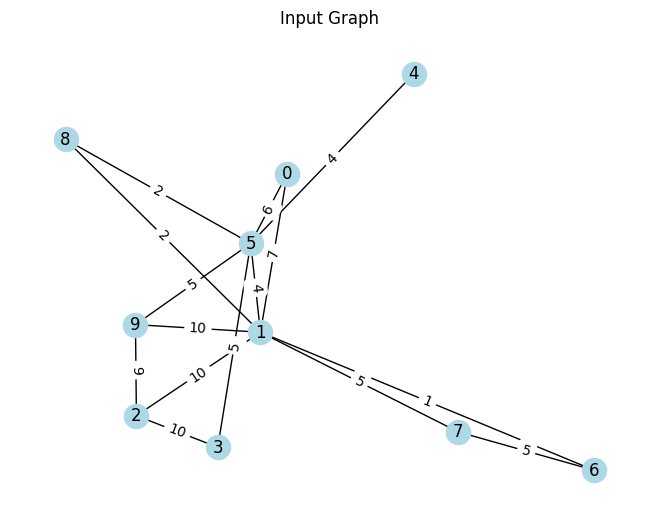

Starting parameter tuning...


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\quantum_instance.py:135: DeprecationWarning: The class qiskit.aqua.QuantumInstance is deprecated. It was moved/refactored to qiskit.utils.QuantumInstance (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_class('aqua.QuantumInstance',
C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\aqua\components\optimizers\optimizer.py:49: DeprecationWarning: The package qiskit.aqua.components.optimizers is deprecated. It was moved/refactored to qiskit.algorithms.optimizers (pip install qiskit-terra). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('aqua.components.optimizers',


Optimization results:
Best θ: 2.4161
Best γ: -0.3806
Best score: 0.0425

Running with tuned parameters...

Top solutions:
1. Path: [1, 5, 9], Length: 9, Count: 8
2. Path: [1, 9], Length: 10, Count: 396
3. Path: [1, 2, 9], Length: 19, Count: 5

Final circuit:


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\tools\pi_check.py:49: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  if not hasattr(inpt._symbol_expr, "expr_free_symbols"):


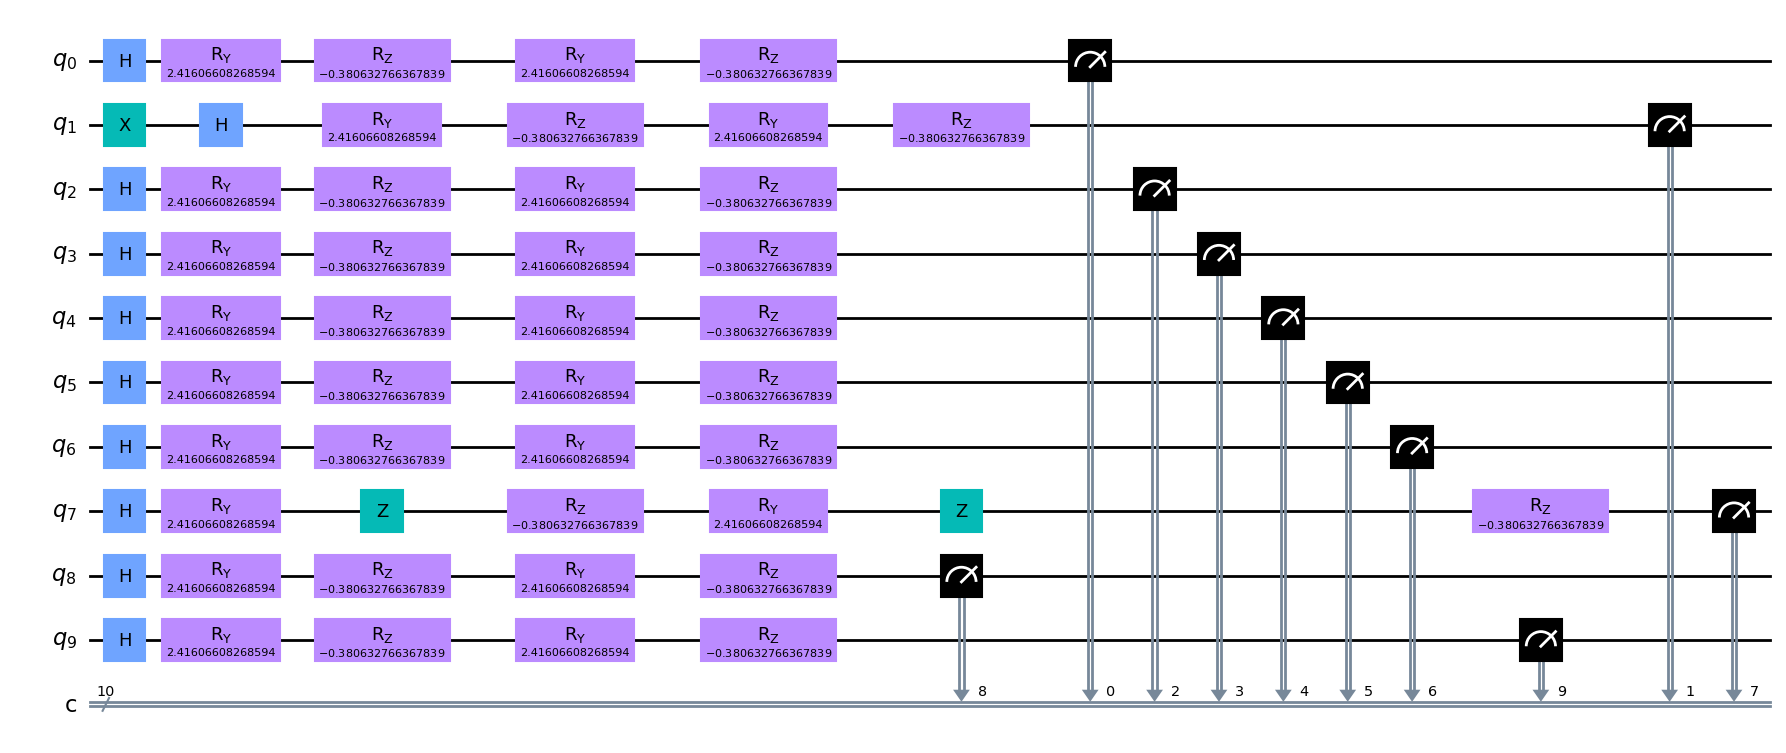

In [15]:
G = nx.Graph()
G.add_weighted_edges_from(weighted_edges)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Input Graph")
plt.show()

run_example(G, 1, 9)

- function to get the max_theta and max_gamma in the search space

In [58]:
import math

def get_max_best_theta_max_best_gamma(G,start,end):
    # Initialize solver
    solver = QuantumShortestPathSolver(G, start, end) 
    # Run parameter tuning
    print("Starting parameter tuning...")
    tuner = ParameterTuner(solver, shots=2048) #shots=512
    thetas = np.linspace(0, np.pi, 10)
    gammas = np.linspace(0, np.pi/2, 10)
    scores = np.zeros((10, 10))
    max_theta = -math.inf
    max_gamma = -math.inf
    save_best_gamma_theta=[]
    for i, theta in enumerate(thetas):
        for j, gamma in enumerate(gammas):         
            scores[i,j] = tuner.objective_function([theta, gamma])
            best_theta, best_gamma = tuner.tune_parameters([theta, gamma],maxiter=60)
            best_theta = round(best_theta,4)
            best_gamma = round(best_gamma,4)
            save_best_gamma_theta.append({"best_theta":best_theta, "best_gamma": best_gamma, "score":scores[i,j]})
            if best_theta > max_theta:
                max_theta = best_theta
            if best_gamma > max_gamma:
                max_gamma = best_gamma
    print("max_theta:", max_theta, "max_gamma:", max_gamma)
    return {"max_theta":max_theta, "max_gamma": max_gamma, "all_theta_gamma":save_best_gamma_theta}
    

param_info = get_max_best_theta_max_best_gamma(G, 3, 9)   

Starting parameter tuning...
max_theta: 3.1416 max_gamma: 3.6282


In [59]:
for item in param_info["all_theta_gamma"]:
    if item["best_theta"] == param_info["max_theta"]:
        print(item)

{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(2.3963), 'score': np.float64(-4.8828125e-05)}


In [60]:
for item in param_info["all_theta_gamma"]:
    if item["best_gamma"] == param_info["max_gamma"]:
        print(item)

{'best_theta': np.float64(0.3976), 'best_gamma': np.float64(3.6282), 'score': np.float64(0.0)}


In [66]:
#for item in param_info["all_theta_gamma"]:
#   print(item)

- run NonGrover Shortest Path with custom theta and gamma values

Starting parameter tuning...

Running with tuned parameters...

Top solutions:
1. Path: [1, 5, 9], Length: 9, Count: 2
2. Path: [1, 9], Length: 10, Count: 519
3. Path: [1, 2, 9], Length: 19, Count: 3

Final circuit:


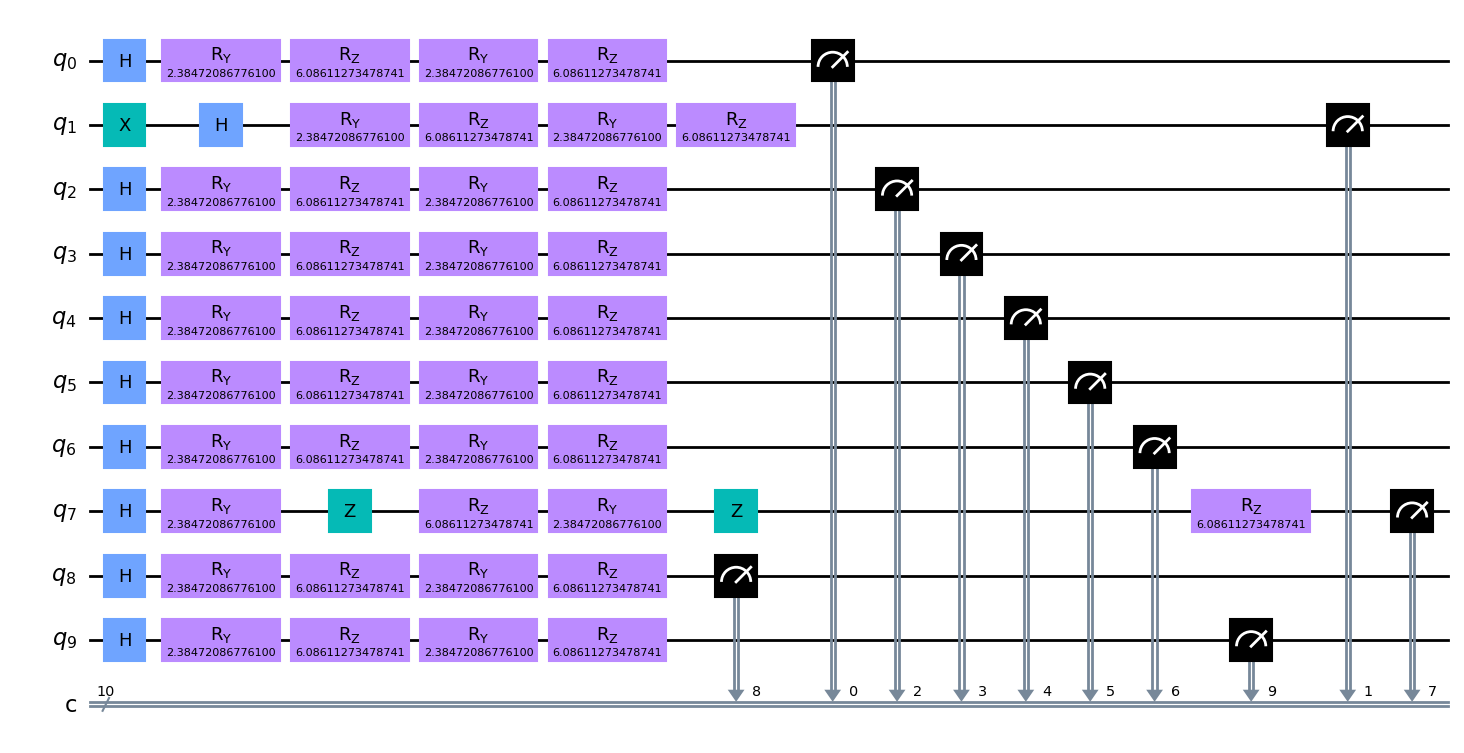

In [64]:
#max_best_theta
run_custom_tuning_example(G, 1, 9, 3.1416, 2.3963)

Starting parameter tuning...

Running with tuned parameters...

Top solutions:
1. Path: [1, 5, 9], Length: 9, Count: 1
2. Path: [1, 9], Length: 10, Count: 1
3. Path: [1, 2, 9], Length: 19, Count: 1

Final circuit:


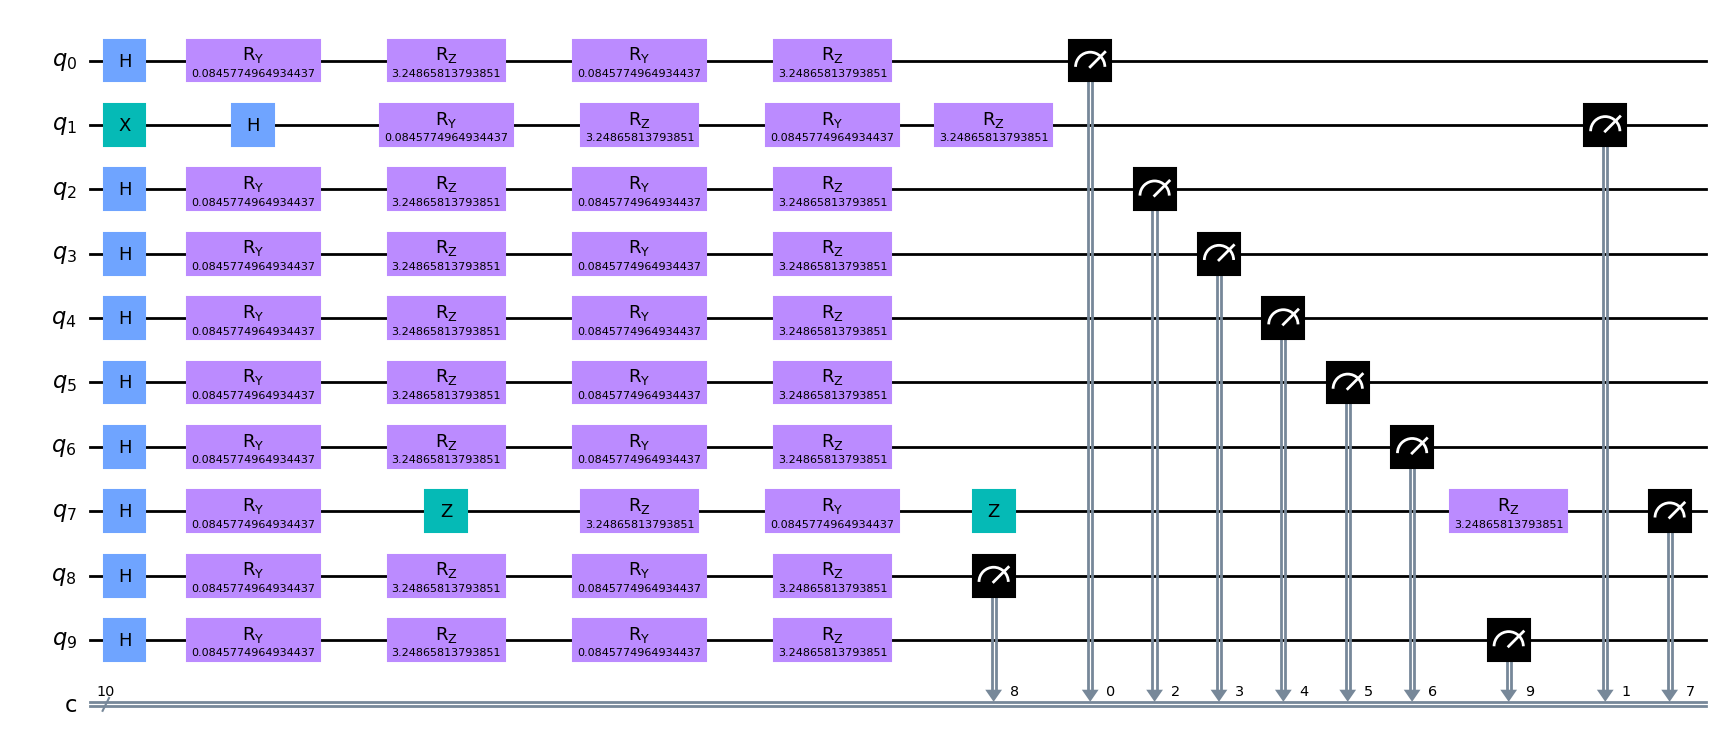

In [65]:
#max_best_gamma
run_custom_tuning_example(G, 1, 9, 0.3976, 3.6282)

In [17]:
#print all paths to have more examples for testing
for i in vertices:
    for j in vertices:
        if i != j:
            start_node = str(i)
            end_node = str(j)
            path, cost = dijkstra(graph_dict, start_node, end_node)
            if path:
                print(f"The shortest path from {start_node} to {end_node} is: {' -> '.join(path)} with a cost of {cost}")
            else:                  
                print(f"No path found from {start_node} to {end_node}")          

The shortest path from 0 to 1 is: 0 -> 1 with a cost of 7
The shortest path from 0 to 2 is: 0 -> 1 -> 2 with a cost of 17
The shortest path from 0 to 3 is: 0 -> 5 -> 3 with a cost of 11
The shortest path from 0 to 4 is: 0 -> 5 -> 4 with a cost of 10
The shortest path from 0 to 5 is: 0 -> 5 with a cost of 6
The shortest path from 0 to 6 is: 0 -> 1 -> 6 with a cost of 8
The shortest path from 0 to 7 is: 0 -> 1 -> 7 with a cost of 12
The shortest path from 0 to 8 is: 0 -> 5 -> 8 with a cost of 8
The shortest path from 0 to 9 is: 0 -> 5 -> 9 with a cost of 11
The shortest path from 1 to 0 is: 1 -> 0 with a cost of 7
The shortest path from 1 to 2 is: 1 -> 2 with a cost of 10
The shortest path from 1 to 3 is: 1 -> 5 -> 3 with a cost of 9
The shortest path from 1 to 4 is: 1 -> 5 -> 4 with a cost of 8
The shortest path from 1 to 5 is: 1 -> 5 with a cost of 4
The shortest path from 1 to 6 is: 1 -> 6 with a cost of 1
The shortest path from 1 to 7 is: 1 -> 7 with a cost of 5
The shortest path fro

- (9,6) example for which both Grover and NonGrover Shortest Path fail to find the shortest path

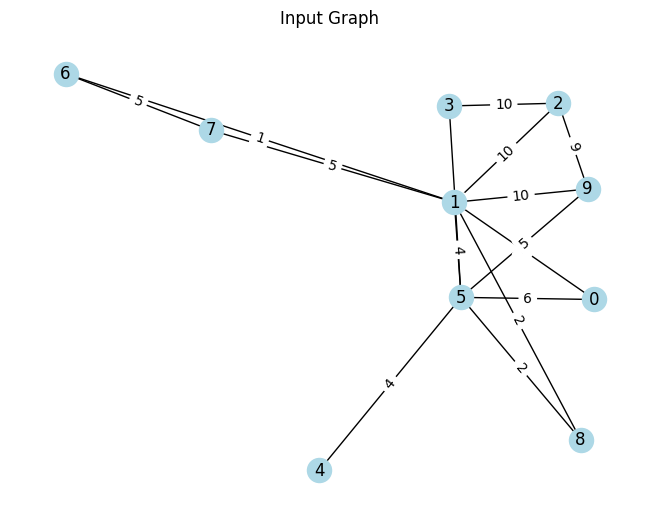

iterations: 18
Measurement results:
{'0100011011': 518, '0100011001': 504, '0111000111': 1, '1100010011': 1}


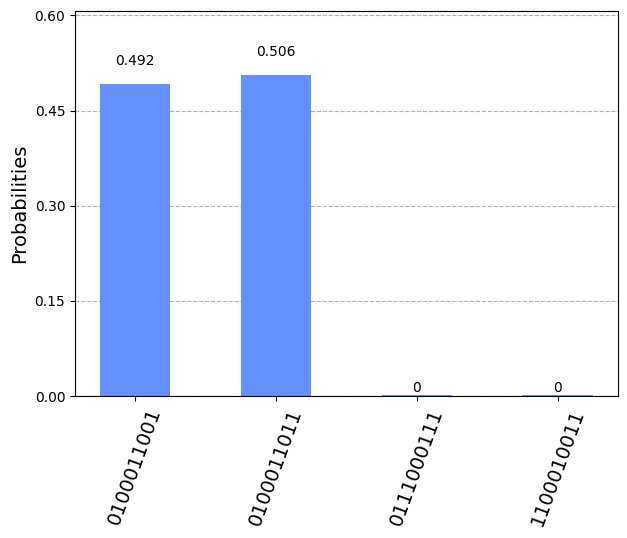

path: [1, 5, 6, 8, 9] start: 9 end: 6
path: [1, 5, 6, 9] start: 9 end: 6
path: [1, 2, 3, 7, 8, 9] start: 9 end: 6
path: [0, 1, 5, 8, 9] start: 9 end: 6
No valid path found.


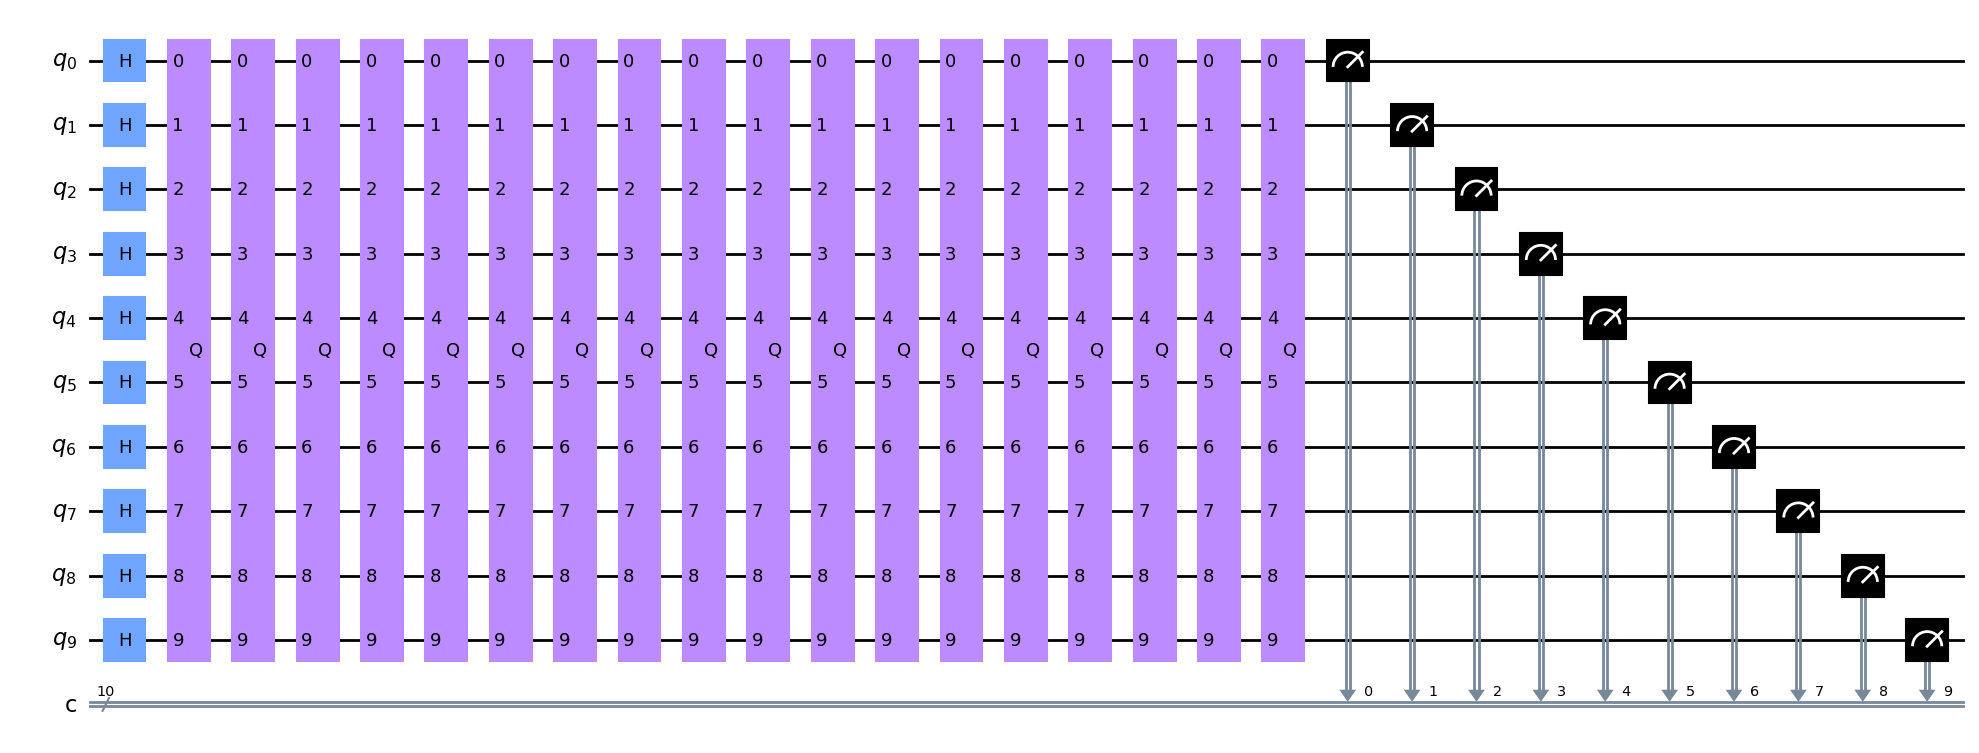

In [18]:
run_GroverGraphShortestPath(G, 9, 6)

Starting parameter tuning...
Optimization results:
Best θ: 0.7854
Best γ: 0.3927
Best score: -0.0000

Running with tuned parameters...
No valid paths found.

Final circuit:


C:\Users\slipo\anaconda3\envs\old_qiskit\lib\site-packages\qiskit\circuit\tools\pi_check.py:49: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  if not hasattr(inpt._symbol_expr, "expr_free_symbols"):


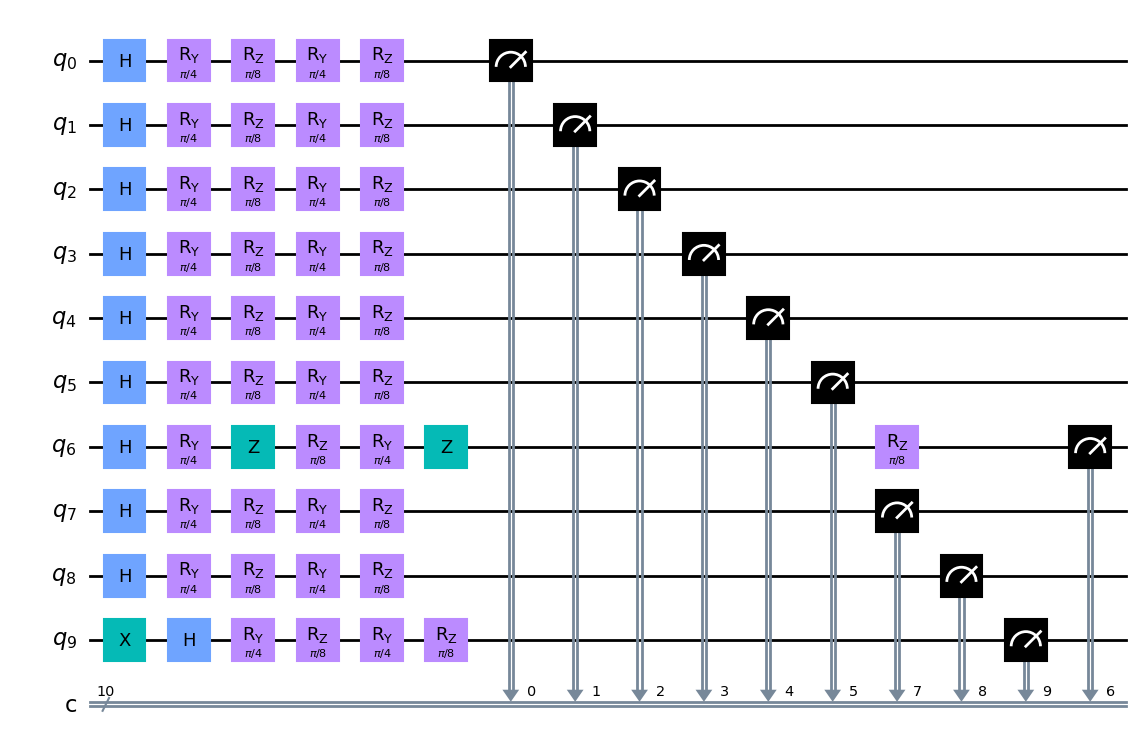

In [19]:
run_example(G, 9, 6)

- some variations for the same (9,6) example, but still "No valid paths found."

In [71]:
param_info = get_max_best_theta_max_best_gamma(G, 9, 6)   

Starting parameter tuning...
max_theta: 3.1416 max_gamma: 1.5708


In [72]:
for item in param_info["all_theta_gamma"]:
    if item["best_theta"] == param_info["max_theta"]:
        print(item)

{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(0.0), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(0.1745), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(0.3491), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(0.5236), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(0.6981), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(0.8727), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(1.0472), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(1.2217), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(1.3963), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}


Starting parameter tuning...
Optimization results:
Best θ: 3.1416
Best γ: 0.1745
Best score: -0.0000

Running with tuned parameters...
No valid paths found.

Final circuit:


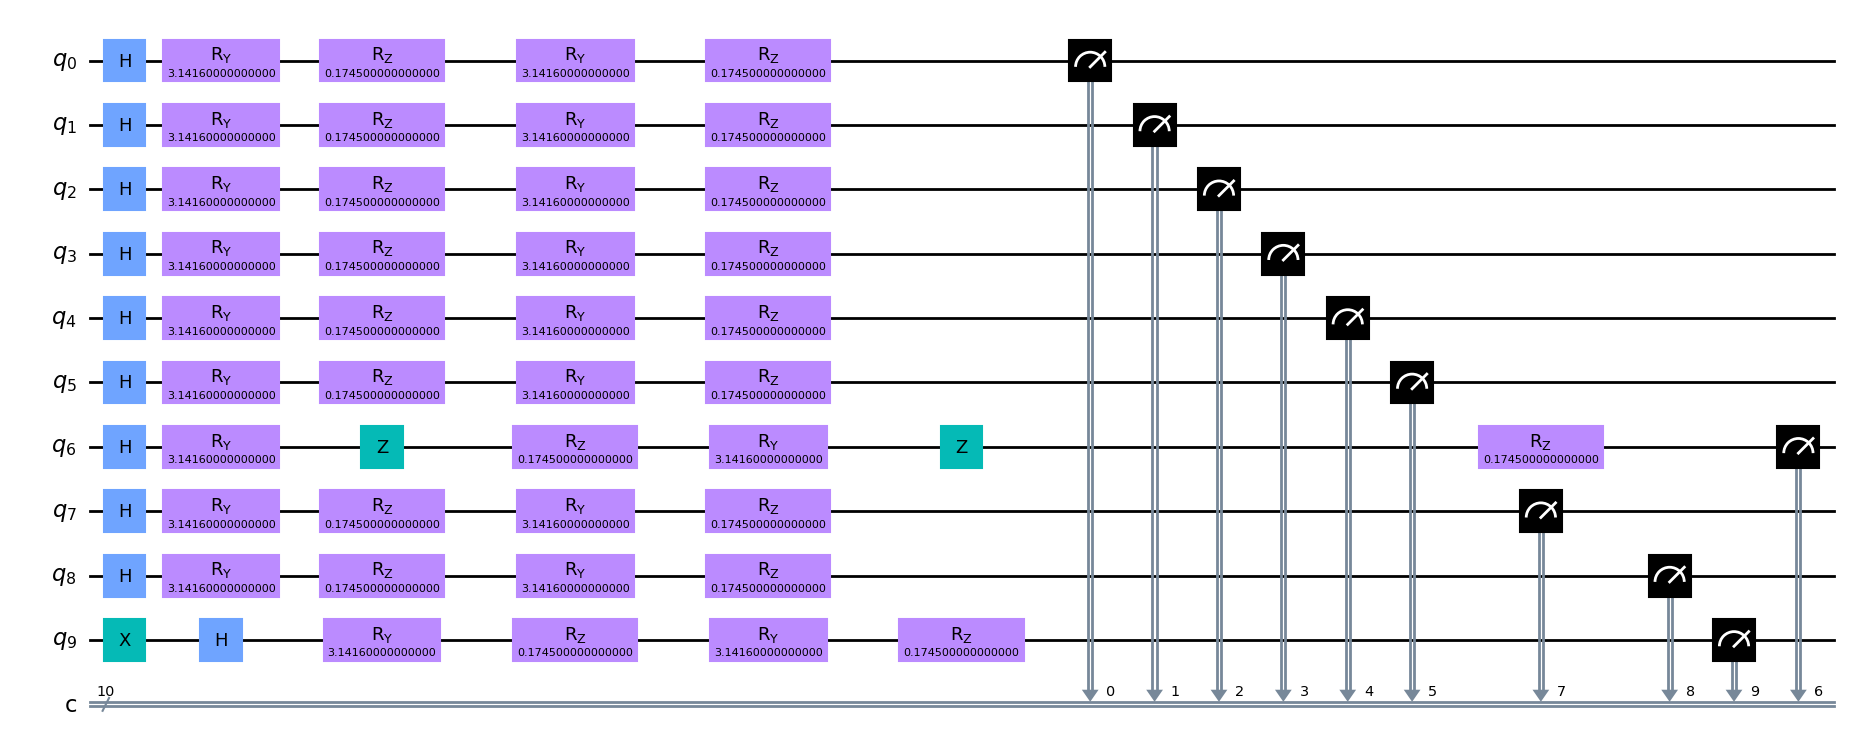

In [29]:
#max_best_theta
run_custom_tuning_example(G, 9, 6, 3.1416, 0.1745)

Starting parameter tuning...
Optimization results:
Best θ: 3.1416
Best γ: 0.1745
Best score: -0.0000

Running with tuned parameters...
No valid paths found.

Final circuit:


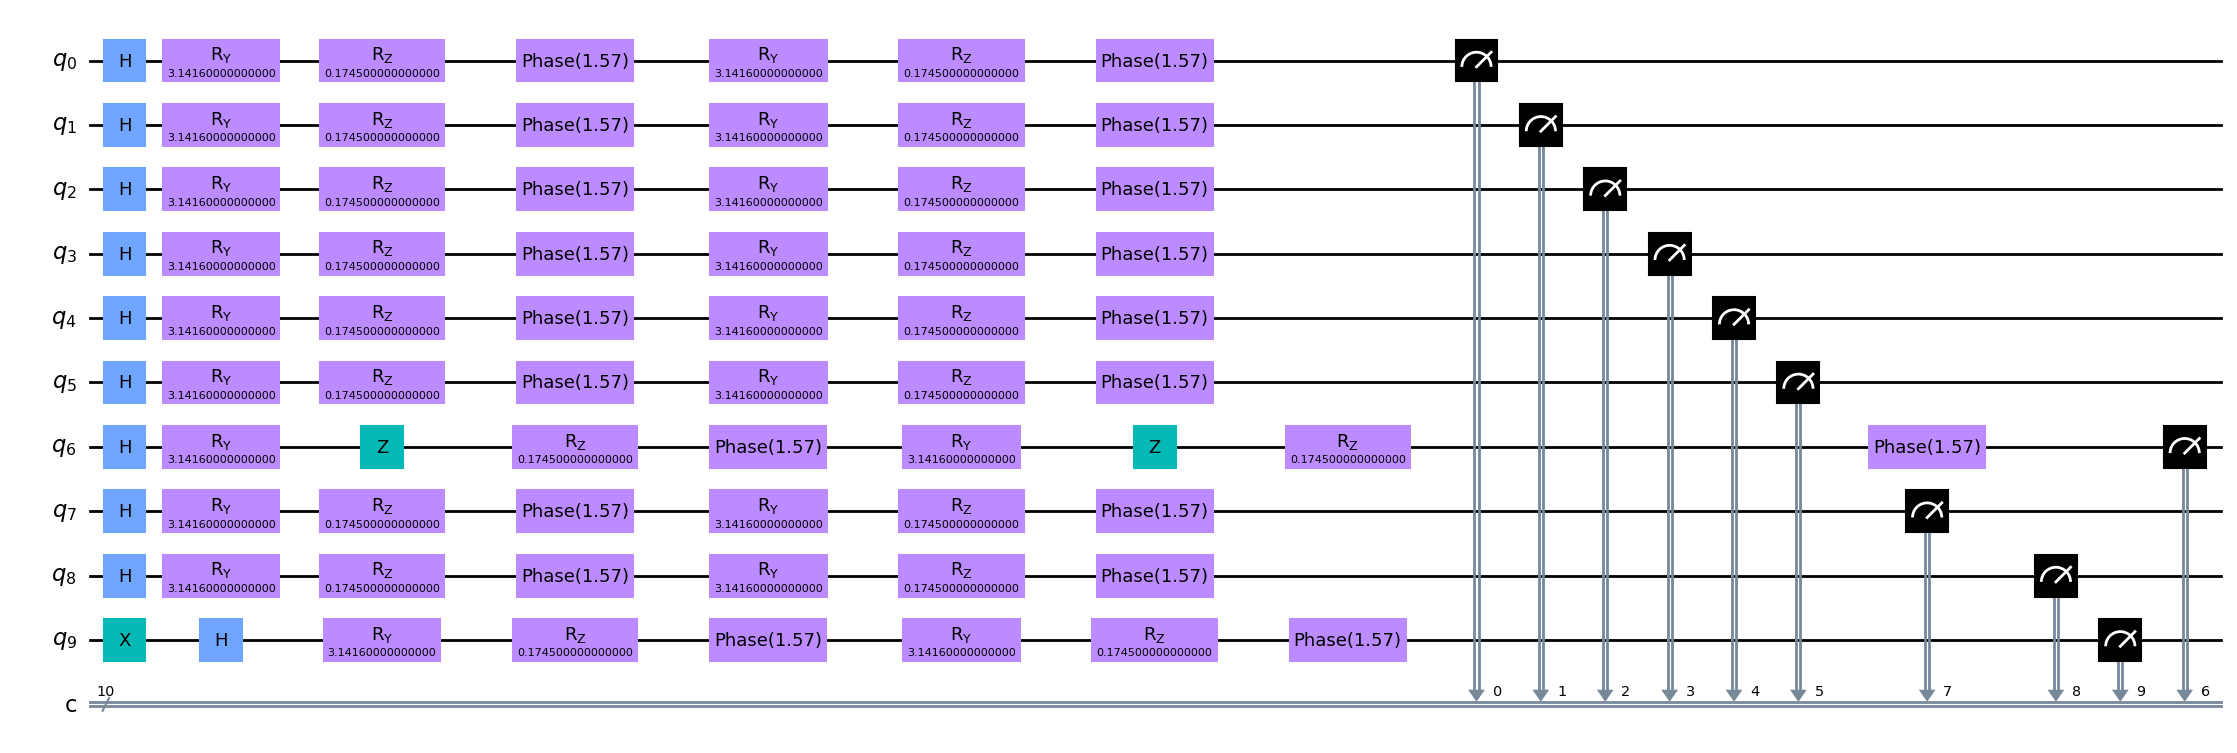

In [22]:
#max_best_theta with additional pi/2 phase applied
run_custom_tuning_example(G, 9, 6, 3.1416, 0.1745, True, np.pi/2)

In [94]:
for item in param_info["all_theta_gamma"]:
    if item["best_gamma"] == param_info["max_gamma"]:
        print(item)

{'best_theta': np.float64(0.0), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(0.3491), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(0.6981), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(1.0472), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(1.3963), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(1.7453), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(2.0944), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(2.4435), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(2.7925), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}
{'best_theta': np.float64(3.1416), 'best_gamma': np.float64(1.5708), 'score': np.float64(0.0)}


Starting parameter tuning...
Optimization results:
Best θ: 3.1416
Best γ: 1.5708
Best score: -0.0000

Running with tuned parameters...
No valid paths found.

Final circuit:


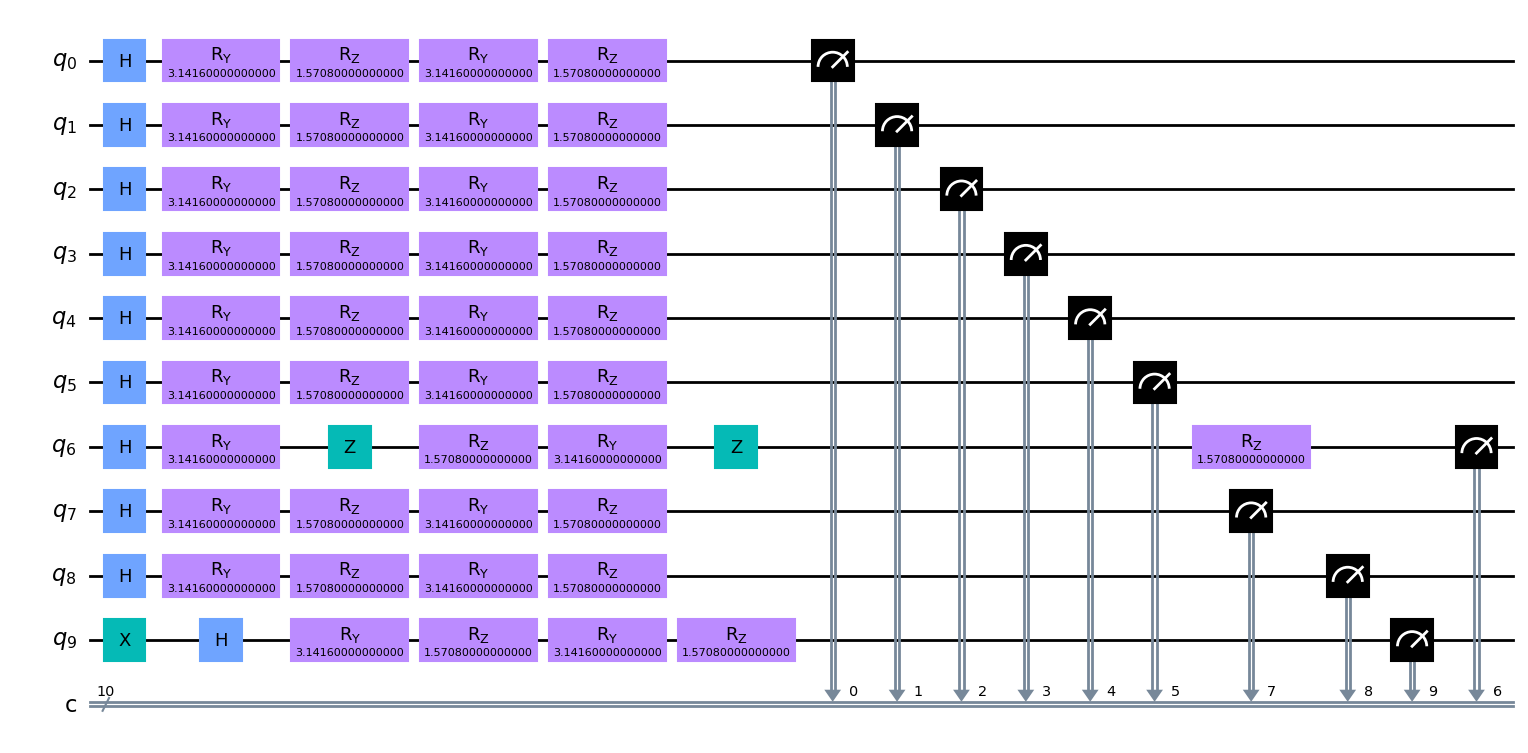

In [18]:
#max_best_gamma
run_custom_tuning_example(G, 9, 6, 3.1416, 1.5708)

- correct smallest path example

Starting parameter tuning...
Optimization results:
Best θ: 2.6629
Best γ: -0.0866
Best score: 0.0013

Running with tuned parameters...

Top solutions:
1. Path: [0, 1, 2], Length: 17, Count: 24

Final circuit:


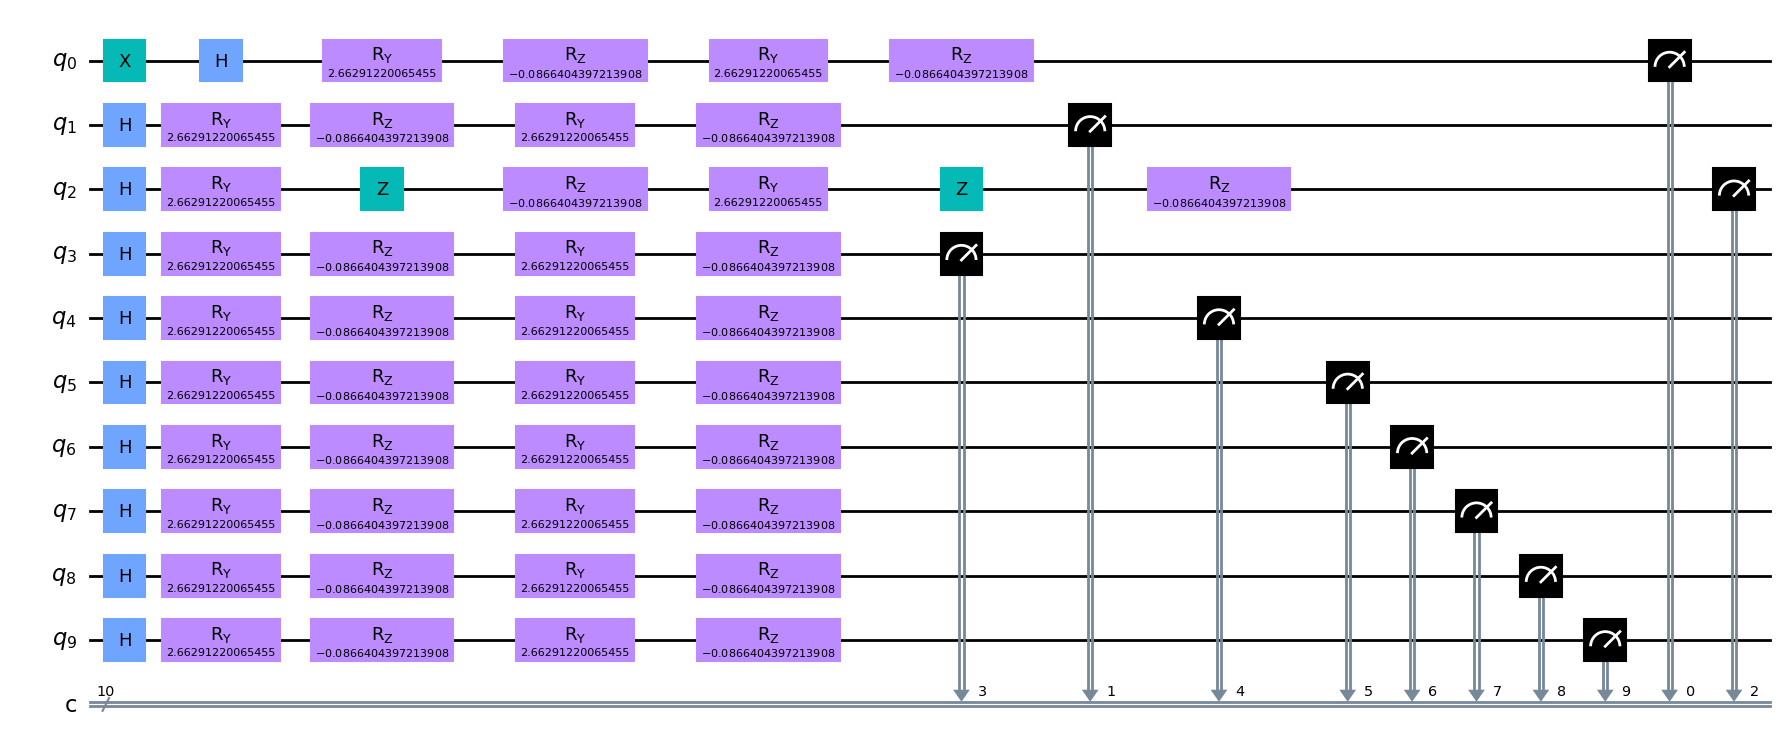

In [26]:
run_example(G, 0, 2)

Starting parameter tuning...
Optimization results:
Best θ: 2.2476
Best γ: 2.1773
Best score: 0.0010

Running with tuned parameters...

Top solutions:
1. Path: [0, 1, 2], Length: 17, Count: 20

Final circuit:


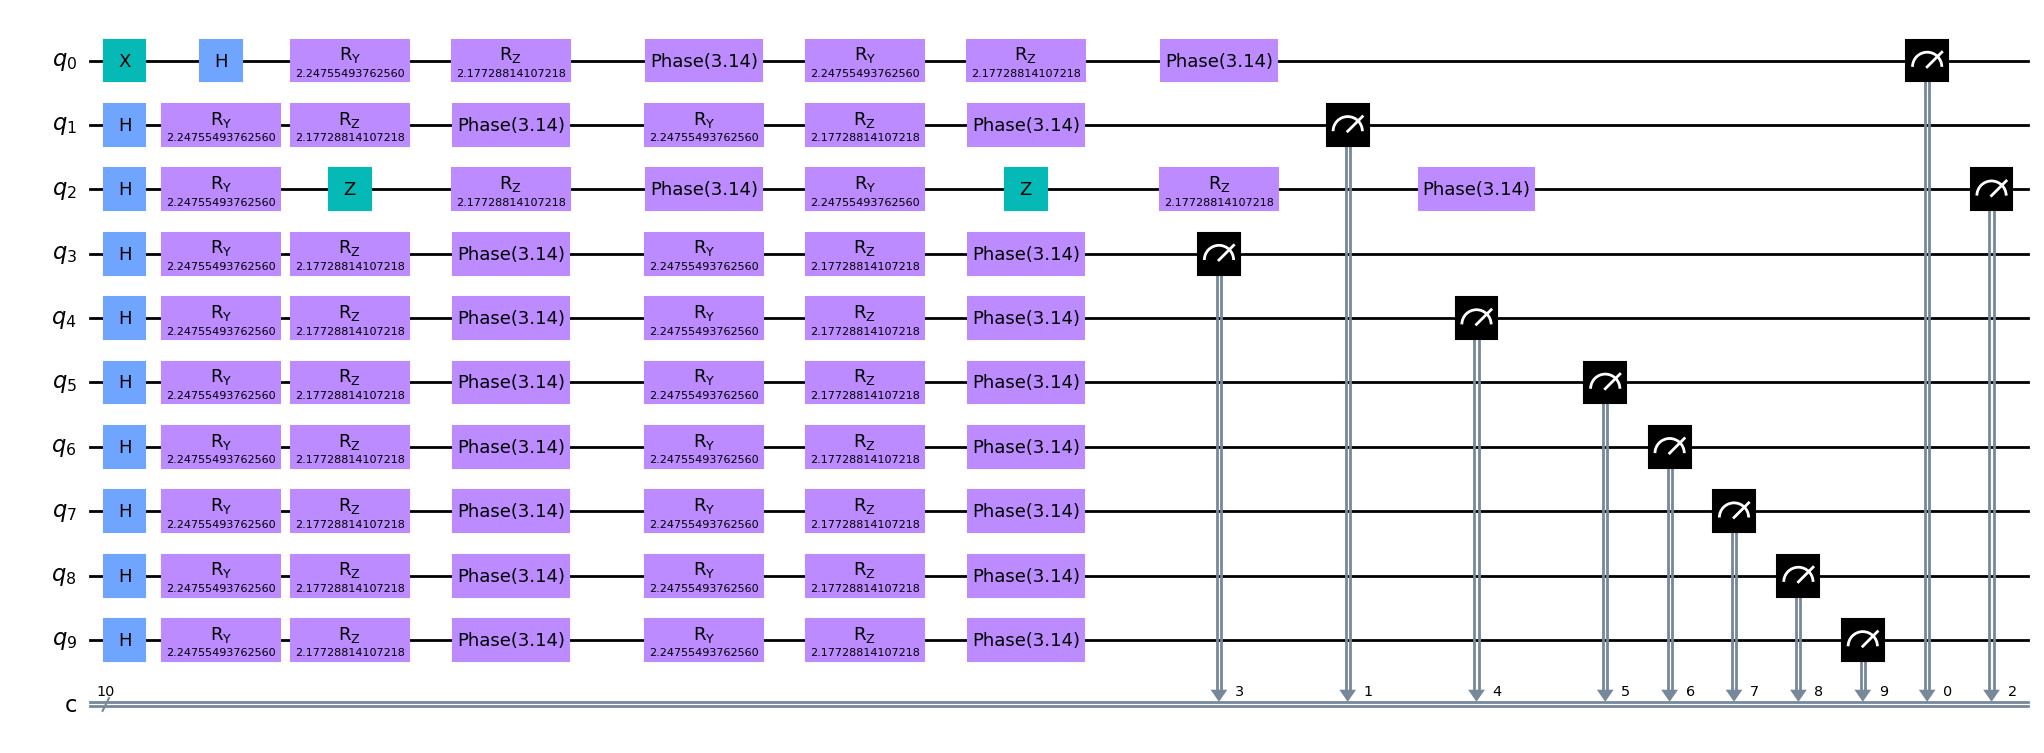

In [27]:
run_example(G, 0, 2, True, np.pi)

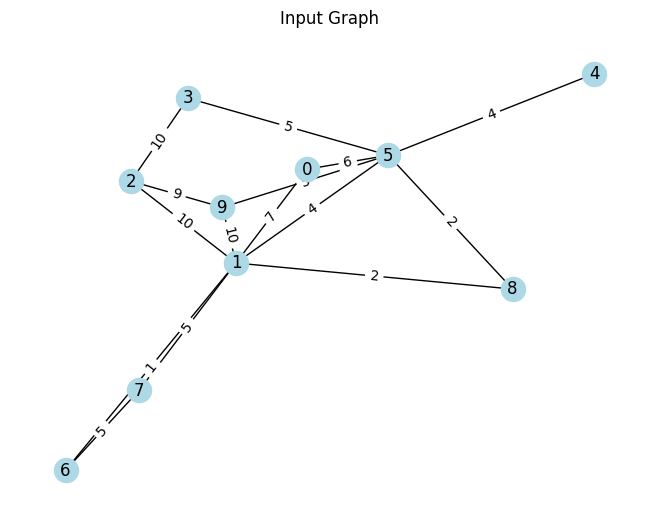

iterations: 26
Measurement results:
{'1011010101': 1, '0000100011': 1, '1110000000': 1016, '0001011011': 1, '1000111010': 1, '0011110010': 1, '0111111111': 1, '1001010101': 1, '0000001001': 1}


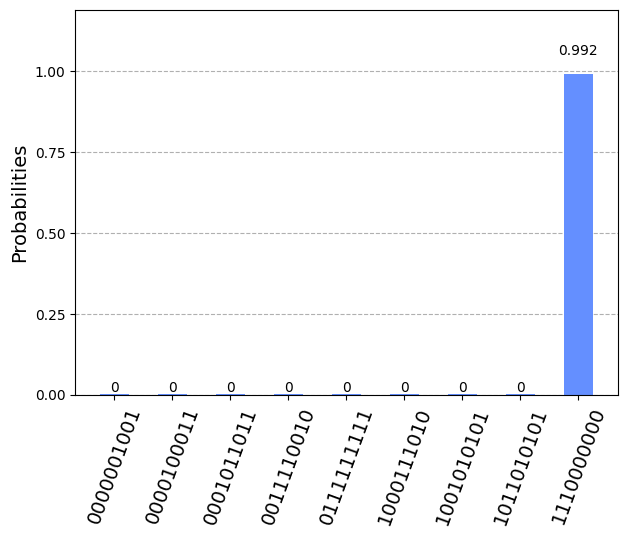

path: [0, 1, 2] start: 0 end: 2
path: [0, 2, 3, 5, 7, 9] start: 0 end: 2
path: [4, 8, 9] start: 0 end: 2
path: [3, 5, 6, 8, 9] start: 0 end: 2
path: [0, 4, 5, 6, 8] start: 0 end: 2
path: [2, 3, 4, 5, 8] start: 0 end: 2
path: [1, 2, 3, 4, 5, 6, 7, 8, 9] start: 0 end: 2
path: [0, 3, 5, 7, 9] start: 0 end: 2
path: [6, 9] start: 0 end: 2

Found shortest paths:
Path: [0, 1, 2], Length: 17


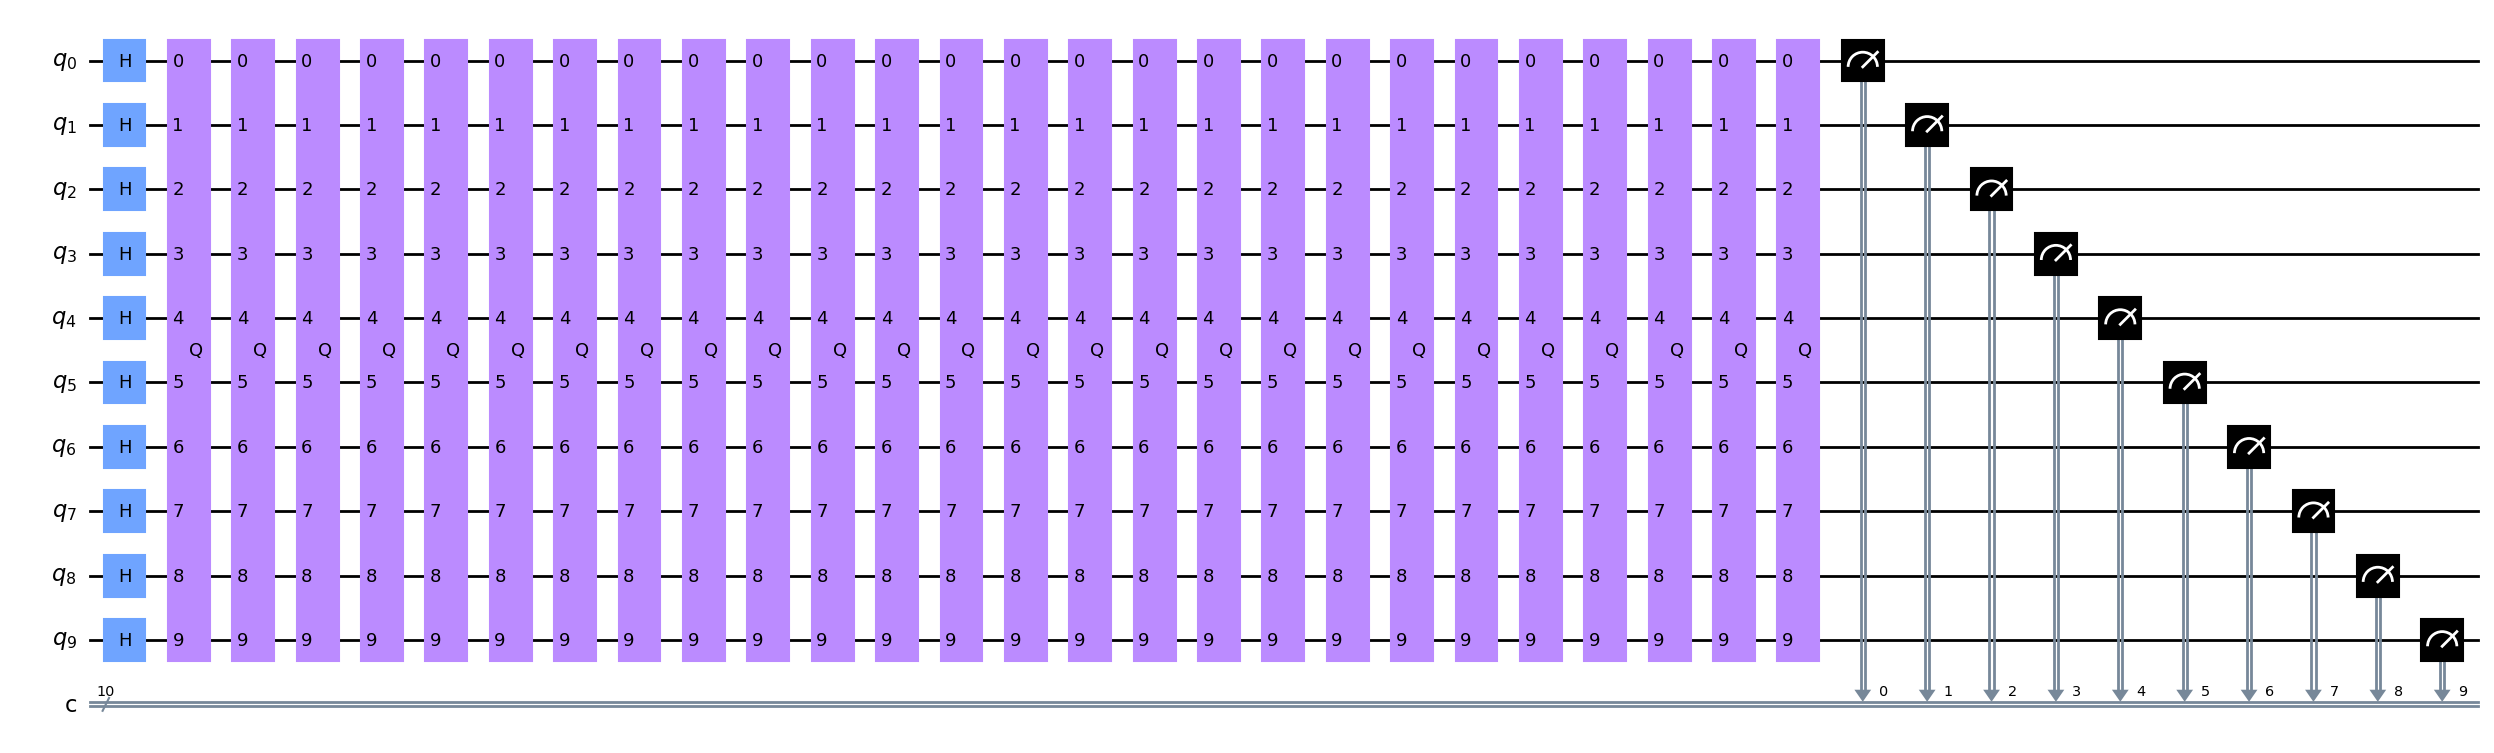

In [101]:
run_GroverGraphShortestPath(G, 0, 2)

# 7. Conclusions

- Working with the DeepSeek was very productive, resulting into 2 interesting approaches for the shortest path in a weighted graph.
- The initial code versions were a good starting point for further code modification and updates.
- For (9,6) example, both Grover and NonGrover Shortest Path codes fail to find the shortest path, so further investigation is needed into these issues.

# Appendix

- creating a custom 2 x 2 unitary matrix that applies the phase shift on |1> qubit state

Quantum Circuit:
     ┌─────────────┐
q_0: ┤ Phase(0.79) ├
     └─────────────┘

Statevector after applying H gate and the custom phase gate:
[0.70710678+0.j 0.70710678+0.j]


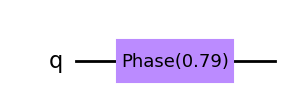

In [134]:
import numpy as np
from qiskit import QuantumCircuit, Aer, execute
from qiskit.extensions import UnitaryGate  # For Qiskit 0.18.1
import matplotlib.pyplot as plt

# Set the phase phi (for example, phi = pi/4)
phi = np.pi / 4

# Create the 2x2 unitary matrix that applies the phase shift on |1>
phase_matrix = np.array([[1, 0],
                         [0, np.exp(1j * phi)]])

# Create the custom UnitaryGate
phase_gate = UnitaryGate(phase_matrix, label=f"Phase({phi:.2f})")

# Build a quantum circuit using the custom phase gate
qc = QuantumCircuit(1)
qc.append(phase_gate, [0])

# Draw the circuit
print("Quantum Circuit:")
print(qc.draw(output='text'))

# (Optional) Simulate the gate's effect on a superposition in order to observe phase kickback.
# Prepare a superposition state, apply the phase gate, and then visualize the output statevector.
from qiskit import Aer

# Use the statevector_simulator backend
backend = Aer.get_backend('statevector_simulator')
qc2 = QuantumCircuit(1)
qc2.h(0)              # Create superposition, state becomes (|0>+|1>)/sqrt(2)
qc2.append(phase_gate, [0])
job = execute(qc2, backend)
result = job.result()
statevector = result.get_statevector(qc2)
print("\nStatevector after applying H gate and the custom phase gate:")
print(statevector)

# For visualization, you can also use qc.draw('mpl')
qc.draw('mpl')
plt.show()